In [23]:
suppressPackageStartupMessages({
    library(Seurat)
    library(tessera)
    library(dplyr)
    library(ggthemes)
    library(ggplot2)
    library(tibble)
    library(pheatmap)
    source('../_common/typing_utils.r')
})

In [24]:
samples = 'EDP1-EDP2-ARB'

In [25]:
rds_dir = paste0("out_rds/", samples)
plot_dir = paste0("diagnostic_plots/", samples, "/5.assign_niches_to_tesseraclusters")
dir.create(plot_dir, showWarnings = FALSE, recursive = TRUE)

# Read in tessera results

In [26]:
tiles <- readRDS(paste0(rds_dir, "/allcells_qc_harmumapclust_lineage[tiles].rds"))

In [27]:
cellstotiles <- readRDS(paste0(rds_dir, "/allcells_qc_harmumapclust_lineage[cellstotiles].rds"))

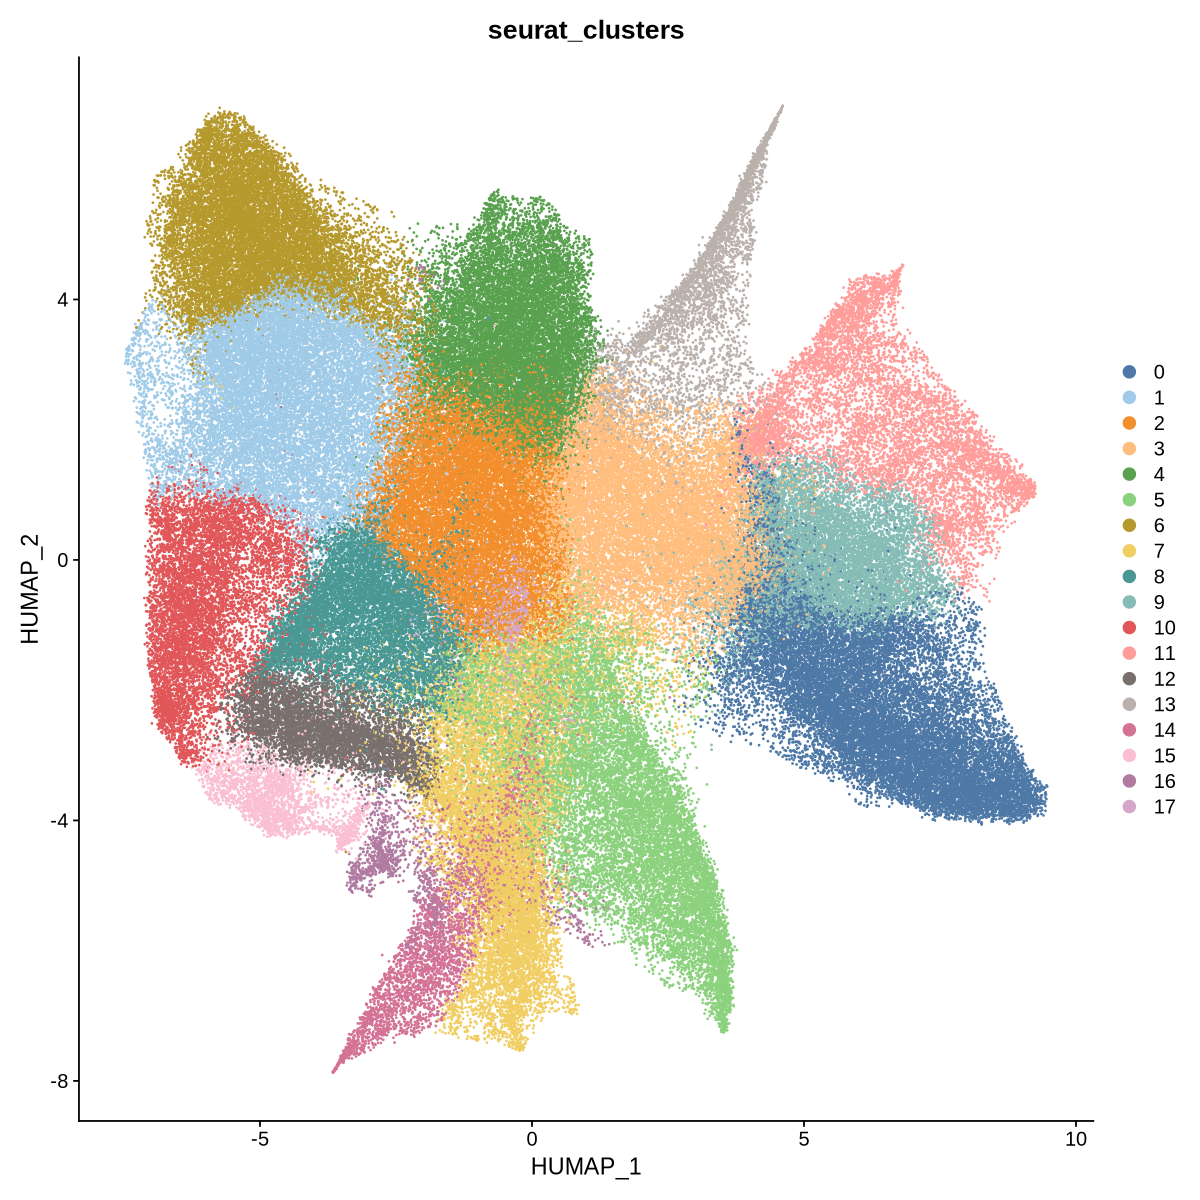

In [28]:
fig.size(10,10)
DimPlot(tiles, group.by = "seurat_clusters", raster = F) + scale_color_tableau("Tableau 20")

In [29]:
# count cell types within each tile
counts <- cellstotiles %>%
  count(tile_id, lineage) %>%
  tidyr::pivot_wider(
    names_from = lineage,
    values_from = n,
    values_fill = 0
  ) %>%
  column_to_rownames("tile_id")

In [30]:
tiles@meta.data[,colnames(counts)] <- 
  counts[colnames(tiles), ]

In [31]:
colnames(counts)

[1] "Endothelial"      "Mural"            "Myeloid"          "Myeloid+Stromal" 
 [5] "Stromal"          "Low quality"      "Adipocyte"        "Neuronal/glial"  
 [9] "Proliferating"    "Mast"             "T/NK"             "B/plasma"        
[13] "Myeloid+B/plasma" "Osteoclast"

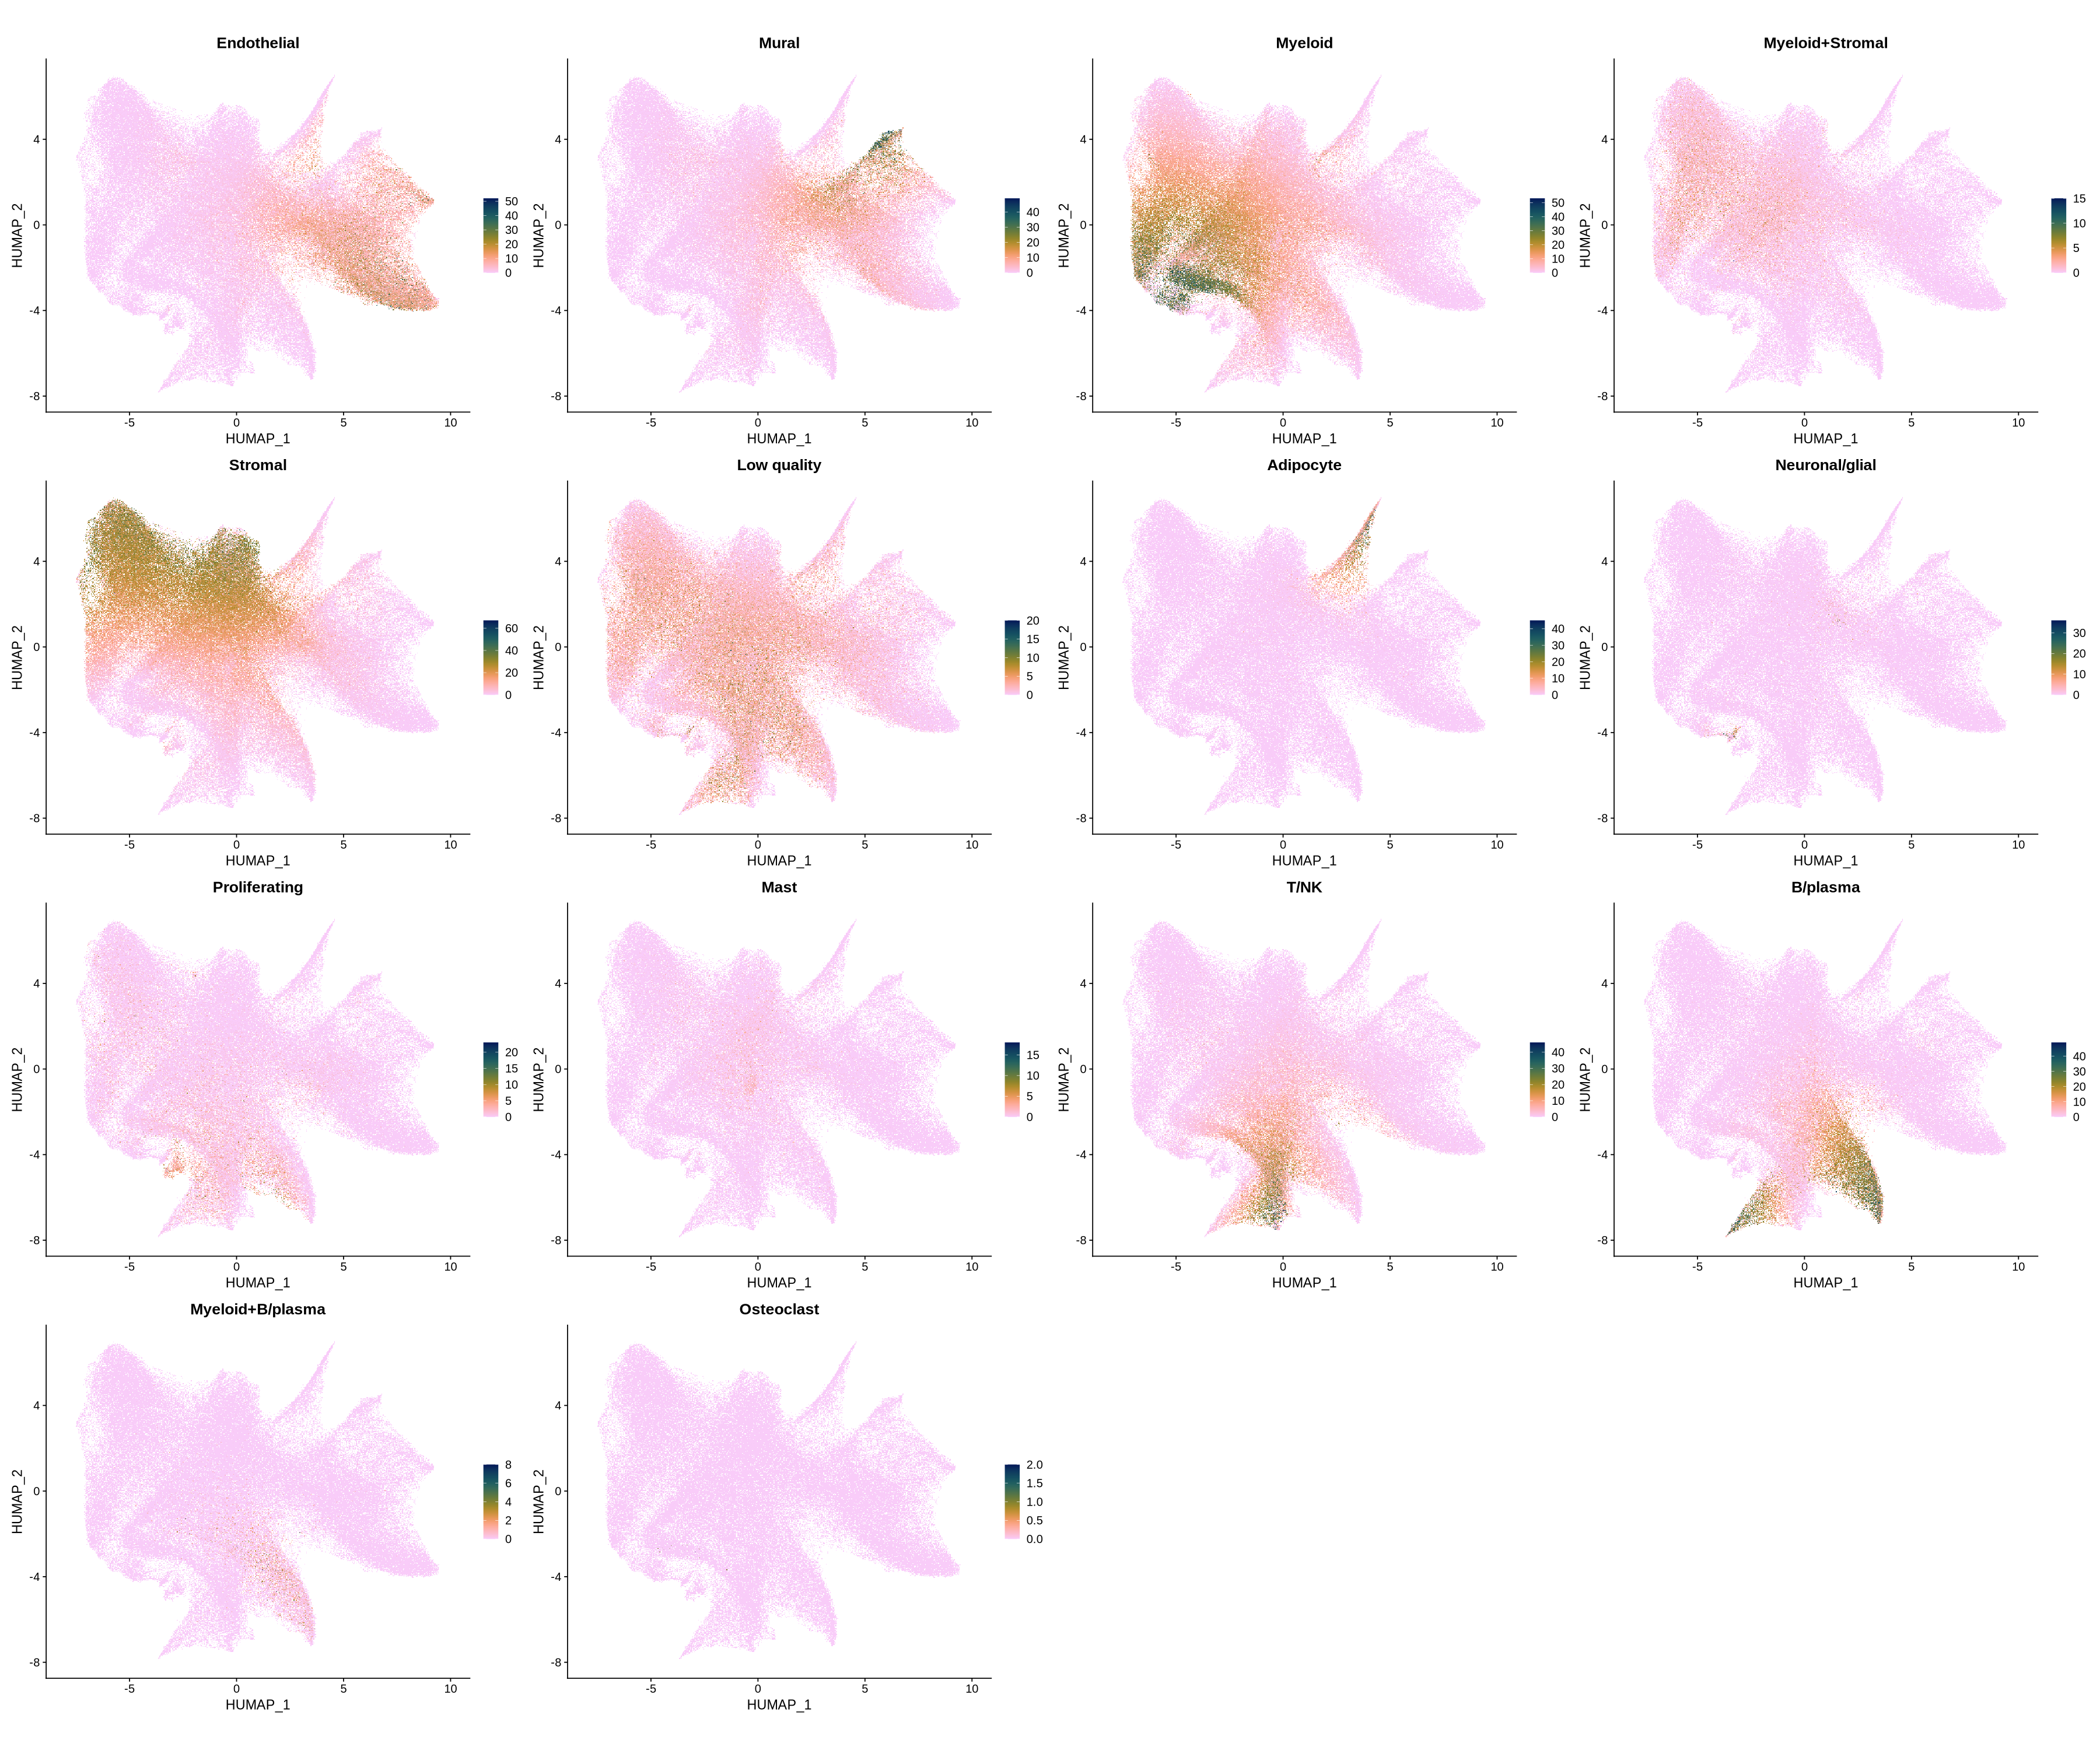

In [32]:
fig.size(25,30)
suppressMessages(FeaturePlot(tiles, features = colnames(counts), ncol = 4, raster=T, order = T) & coord_fixed() &
                 scico::scale_color_scico(palette = 'batlow', direction = -1))

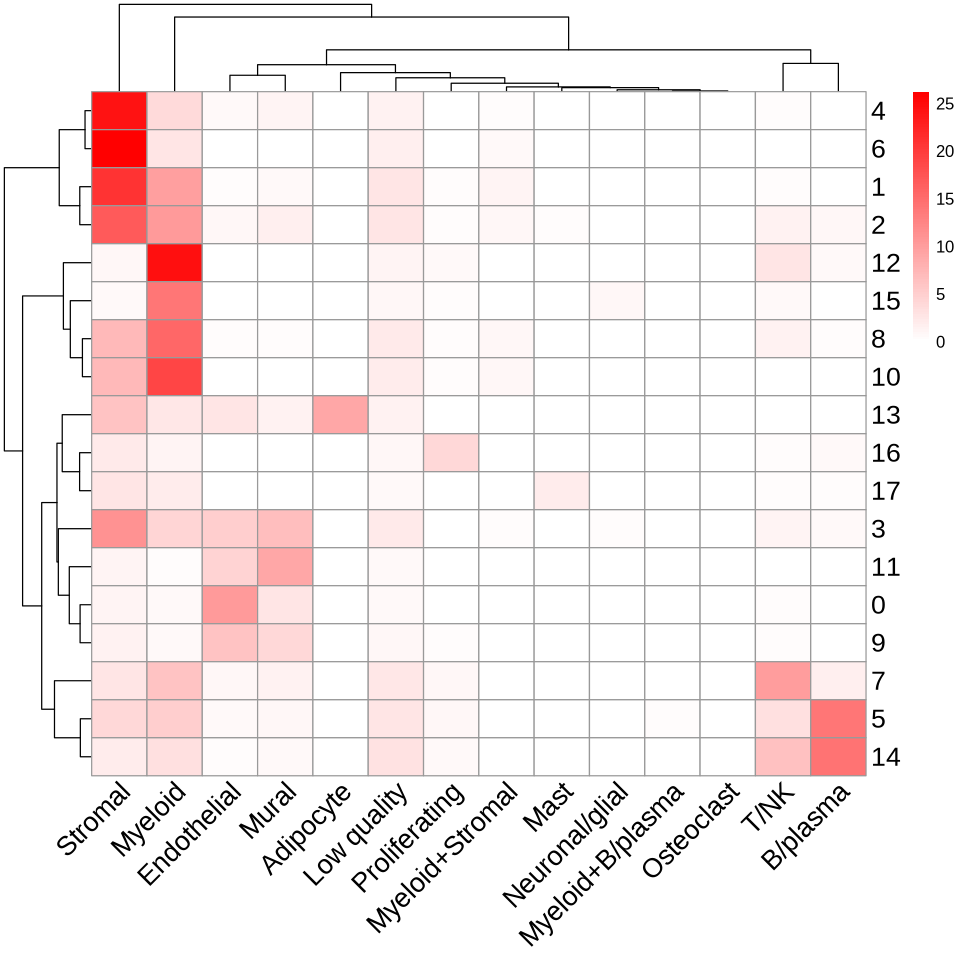

In [33]:
fig.size(8,8)
cluster_means <- tiles[[]] %>%
  group_by(seurat_clusters) %>%
  summarise(across(all_of(colnames(counts)), ~mean(.x, na.rm = TRUE))) %>%
  column_to_rownames("seurat_clusters")
# cluster_means[,"total"] = rowSums(cluster_means)

pheatmap(
  as.matrix(cluster_means),
  angle_col = 45,
  fontsize_row = 16,
  fontsize_col = 16,
  color = colorRampPalette(c("white", "red"))(100)
)

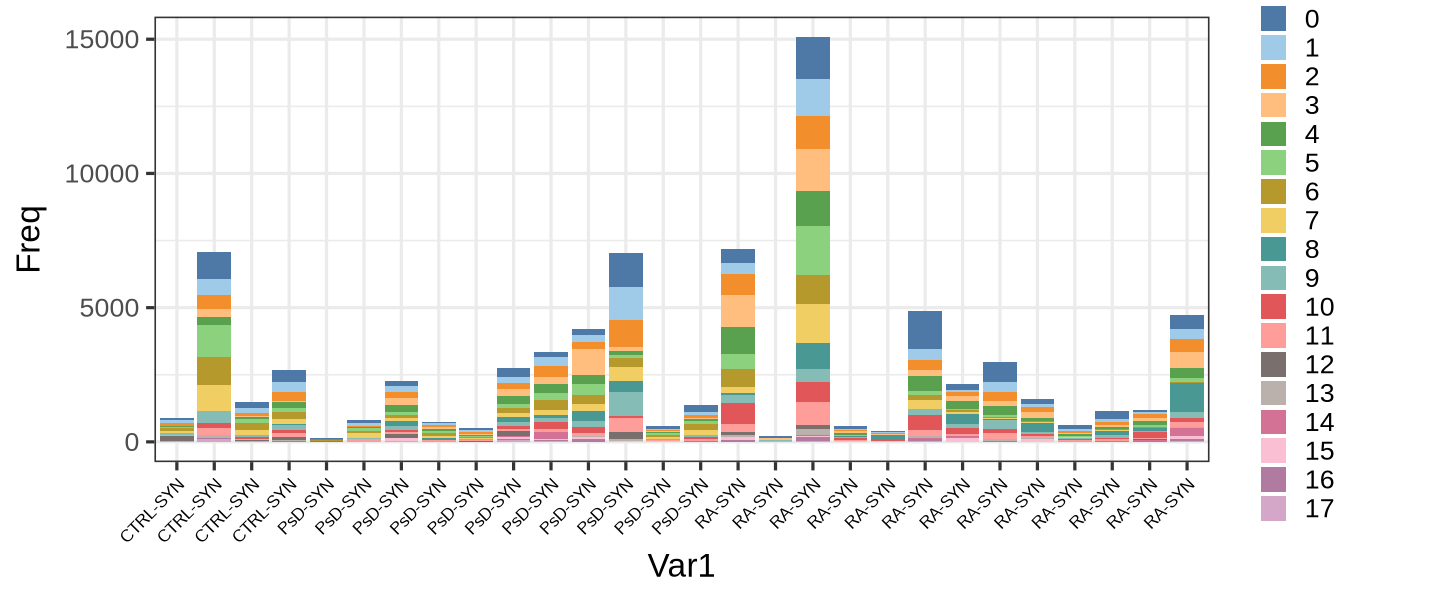

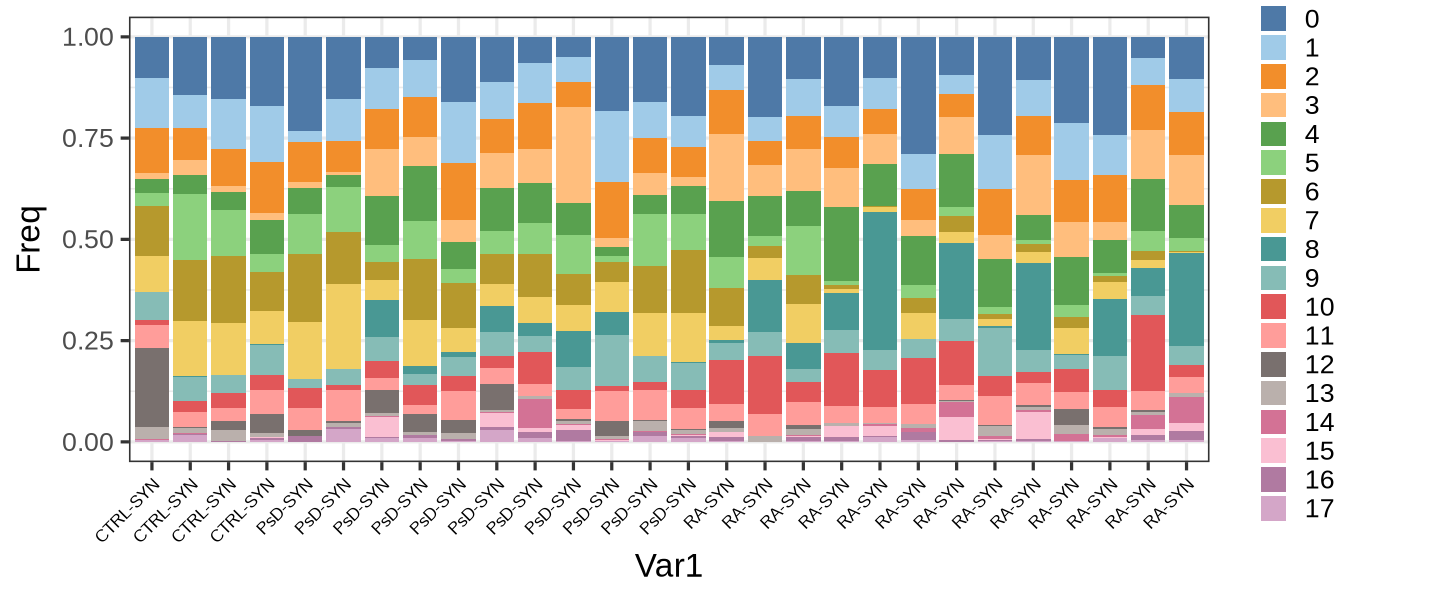

In [111]:
meta_files <- list(
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_CTRL-SYN-EDP1_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-EDP1_assay manifest.csv",
  # "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_RA-SYN-EDP2_assay manifest.csv",
  "/data/srlab/AMP_collab/data/early_disease_synovium/Xenium_PsD-SYN-EDP1_assay manifest.csv"
)

get_subset_and_edp <- function(path) {
  fname <- basename(path)
  # Extract everything between 'Xenium_' and '_assay manifest.csv'
  core <- sub("^Xenium_(.*)_assay manifest\\.csv$", "\\1", fname)
  # Extract EDP (EDP1 or EDP2) from the core
  edp <- sub(".*-(EDP[12])$", "\\1", core)
  # Extract subset (everything before the last dash + EDP)
  subset <- sub(paste0("-", edp, "$"), "", core)
  list(subset = subset, cohort = edp)
}

meta_list <- lapply(meta_files, function(f) {
  dt <- fread(f)
  info <- get_subset_and_edp(f)
  dt[, subset := info$subset]
  dt[, cohort := info$cohort]
  dt
})

metadata <- rbindlist(meta_list, use.names = TRUE, fill = TRUE)

sid_order <- metadata %>%
    distinct(Sample_ID, subset) %>%
    mutate(subset = factor(subset, levels = c("CTRL-SYN", "PsD-SYN", "RA-SYN"))) %>%
    arrange(subset) %>%
    pull(Sample_ID)

sid_labels <- metadata %>%
    distinct(Sample_ID, subset) %>%
    { setNames(.$subset, .$Sample_ID) }

fig.size(5,12)
table(tiles$sid, tiles$seurat_clusters) %>% 
    as.data.frame() %>%
    mutate(Var1 = factor(Var1, levels = sid_order)) %>%
    ggplot(aes(x = Var1, y = Freq, fill = Var2)) + 
    geom_bar(stat = "identity") +
    theme_bw(base_size = 20) +
    theme(axis.text.x = element_text(size=10, angle=45, hjust=1, color="black")) + 
    scale_x_discrete(labels = sid_labels) +
    scale_fill_tableau("Tableau 20", name = "Cell type")

table(tiles$sid, tiles$seurat_clusters) %>% 
    as.data.frame() %>%
    mutate(Var1 = factor(Var1, levels = sid_order)) %>%
    ggplot(aes(x = Var1, y = Freq, fill = Var2)) + 
    geom_bar(stat = "identity", position = "fill") +
    theme_bw(base_size = 20) +
    theme(axis.text.x = element_text(size=10, angle=45, hjust=1, color="black")) + 
    scale_x_discrete(labels = sid_labels) +
    scale_fill_tableau("Tableau 20", name = "Cell type")

# Write results

In [110]:
saveRDS(tiles, file='out_rds/tiles.rds')

In [112]:
saveRDS(xen, file='out_rds/allcells_qc_harm_umap_clusters_annotation_tessera.rds')

# Scratch

# load lib

In [3]:
source("../R/utils.R")
suppressPackageStartupMessages({
    library(Seurat)
    library(stringr)
    library(singlecellmethods)
    library(tidyverse)
    library(tessera)
    library(future)
    library(pheatmap)
    library(RColorBrewer)
    library(circlize)
    library(ComplexHeatmap)
    library(patchwork)
    library(glue)
    library(ggthemes)
    library(ggbeeswarm)
    })

my_conda_path <- "/data/srlab/lsood/miniforge3/envs/tessera_env/share/proj"
Sys.setenv(PROJ_LIB = my_conda_path)

# read in Xenium data and create harmonized embedding 

In [2]:
# Genes as named in spatial panel 
genes_query<-readLines('../../yakir/2.cells_allsamples_LS/spatial_genes.txt')

# Converting gene names from Xenium to AMPp2 
gene_aliases <- list(
  "ATPSCKMT" = "FAM173B", "CCN1" = "CYR61", "CCN2" = "CTGF", "CCN3" = "NOV", "CCN4" = "WISP1", "CCN5" = "WISP2",
  "DLEU1" = "DLEU1-AS1", "ECRG4" = "C2orf40", "EEF1AKNMT" = "METTL13", "ITPRID2" = "SSFA2", "LRATD2" = "FAM84B",
  "MRTFA" = "MKL1", "MRTFB" = "MKL2", "MTRES1" = "C6orf203", "NIBAN1" = "FAM129A", "NOTCH2NLA" = "NOTCH2NL",
  "PACC1" = "TMEM206", "POGLUT2" = "KDELC1", "PRXL2A" = "FAM213A", "PWWP3A" = "MUM1", "RO60" = "TROVE2",
  "SEPTIN5" = "SEPT5", "SEPTIN6" = "SEPT6", "SEPTIN9" = "SEPT9", "SHFL" = "C19orf66", "SOX2-OT" = "SOX2",
  "TAFA5" = "FAM19A5", "TASOR" = "FAM208A", "TASOR2" = "FAM208B"
)

for (gene in genes_query) {
    if (gene %in% names(gene_aliases)) {
        genes_query[which(genes_query == gene)] = gene_aliases[gene]
    }
}

In [6]:
xenium <- Matrix::readMM('../all_cell_qc70tx50g.mtx')
xenium <- t(xenium)
xenium <- as(xenium, 'dgCMatrix')
meta_xenium <- read.csv('../all_cell_qc70tx50g_cellmeta.csv')
rownames(xenium) <- genes_query
colnames(xenium) <- meta_xenium$cell

'as(<dgTMatrix>, "dgCMatrix")' is deprecated.
Use 'as(., "CsparseMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").



In [7]:
xenium <- xenium[, meta_xenium$sid != '8073578857-03-02']
meta_xenium <- meta_xenium[meta_xenium$sid != '8073578857-03-02', ]
xenium.seurat <- CreateSeuratObject(xenium, 
                             meta.data = meta_xenium, 
                             project = 'xenium')
xenium.seurat$orig.ident = 'xenium'

In [13]:
var_genes <- vargenes_vst(xenium, topn = 600, groups = meta_xenium$sid)
length(var_genes)

[1] 1445

In [14]:
mt_ri <- grep("^MT-|^RPL|^RPS|MALAT1|MIR-", row.names(xenium), value = TRUE)
cycle_prolif <- c(Seurat::cc.genes$s.genes, Seurat::cc.genes$g2m.genes)
genes_exclude <- union(mt_ri, cycle_prolif)
var_genes <- var_genes[-which(var_genes %in% genes_exclude)]
length(var_genes)

[1] 1411

In [22]:
missing_hvgs = c('ADIPOQ', 'PLIN1', 'PLIN4', 'MLXIPL', 'AZGP1', 'PLIN5', 'CIDEC', 
                'GYG2', 'LPL', 'C6', 'AQP7', 'NNAT', 'HCAR2', 'LIPE', 'PNPLA3', 
                'AOC3', 'MEST', 'PTPRF', 'CD36', 'SLC2A4', 'HDC', 'IL1RL1', 'MS4A2', 
                'SLC18A2', 'CTSG', 'CMA1', 'KIT', 'GATA2', 'SIGLEC6', 'HPGDS', 'LIF', 
                'HPGD', 'TAL1', 'ENPP3', 'MLPH', 'NTRK1', 'IL18R1', 'P2RX1', 'CD22', 
                'MYB', 'DUX4', 'ADRB1', 'AZGP1', 'TDGF1', 'DRD5', 'PCA3', 'POTEF', 
                'SOX2', 'BOLL', 'POTEI', 'F7', 'COL17A1', 'CXCL8', 'GRM5', 
                'SPDYA', 'CALCB', 'KRT16', 'ANKRD30A', 'PPP1R1C', 'ABCC6', 'MPO', 
                  'CSF3R', 'S100A12', 'KIT')
bad_genes <- readLines('../../yakir/2.cells_allsamples_LS/xenium_bad_genes.txt')
missing_hvgs <- setdiff(missing_hvgs, bad_genes)
var_genes = unique(c(var_genes, missing_hvgs))
length(var_genes)

[1] 1412

In [23]:
xenium.seurat <- xenium.seurat %>% NormalizeData(scale.factor = median(xenium.seurat$nCount_RNA))
VariableFeatures(xenium.seurat) <- var_genes 
xenium.seurat <- xenium.seurat %>% ScaleData()   

Normalizing layer: counts

Centering and scaling data matrix



In [24]:
xenium.seurat <- xenium.seurat %>% RunPCA(verbose = T)

PC_ 1 
Positive:  HLA-DRB1, C1QC, C1QA, CTSS, CD14, SLCO2B1, STAB1, MARCO, CD163, MSR1 
	   LGMN, HLA-DQA1, CYBB, VSIG4, FCGR2A, FCGRT, SIGLEC1, NCF1, CD68, CD4 
	   TYROBP, F13A1, CSF1R, GRN, ITGB2, CTSL, AP1B1, MRC1, PLTP, LILRB5 
Negative:  COL6A1, TIMP3, TNXB, FSTL1, TNC, COL5A1, CLU, MRC2, COL5A2, ANGPTL2 
	   HSPG2, ABI3BP, COL4A1, THY1, PDGFRB, PRSS23, COL18A1, COL4A2, PRG4, NBL1 
	   AEBP1, CFH, WISP2, CTGF, PDGFRA, ACKR3, SERPINH1, CCDC80, APP, CXCL12 
PC_ 2 
Positive:  VWF, SHANK3, PLVAP, PECAM1, SOX18, TIE1, FLT1, ITGB4, EGFL7, CDH5 
	   PODXL, MMRN2, CLEC14A, CCL14, CD34, EPAS1, NOS3, NOTCH4, KDR, ROBO4 
	   BCAM, NES, CLDN5, ADGRL4, HSPG2, SLC9A3R2, CD93, TEK, APLNR, CALCRL 
Negative:  PRG4, CLU, CRTAC1, MRC2, LRP1, HTRA1, FSTL1, ABI3BP, TNXB, CCDC80 
	   WISP2, NBL1, TNC, SEMA3C, COL6A1, ANGPTL2, PDGFRA, VCAM1, TIMP3, COLEC12 
	   ERRFI1, CFB, SOD2, SDC2, ACKR3, C3, MMP3, COL5A2, ANPEP, COMP 
PC_ 3 
Positive:  VWF, PLVAP, ENG, SHANK3, C1QC, C1QA, HSPG2, MARCO, SOX18, FCGR

In [31]:
samplemeta = read_csv('../../yakir/samplemeta.csv')

Rows: 24 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): sid, slideid
lgl (3): ra, psa, control

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
slideids = xenium.seurat[[]] %>% 
    select('sid') %>% 
    left_join(samplemeta[c('sid', 'slideid')]) %>% 
    pull('slideid') 

xenium.seurat <- AddMetaData(xenium.seurat, slideids, col.name = 'slideid')

Joining with `by = join_by(sid)`


Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 91954500)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



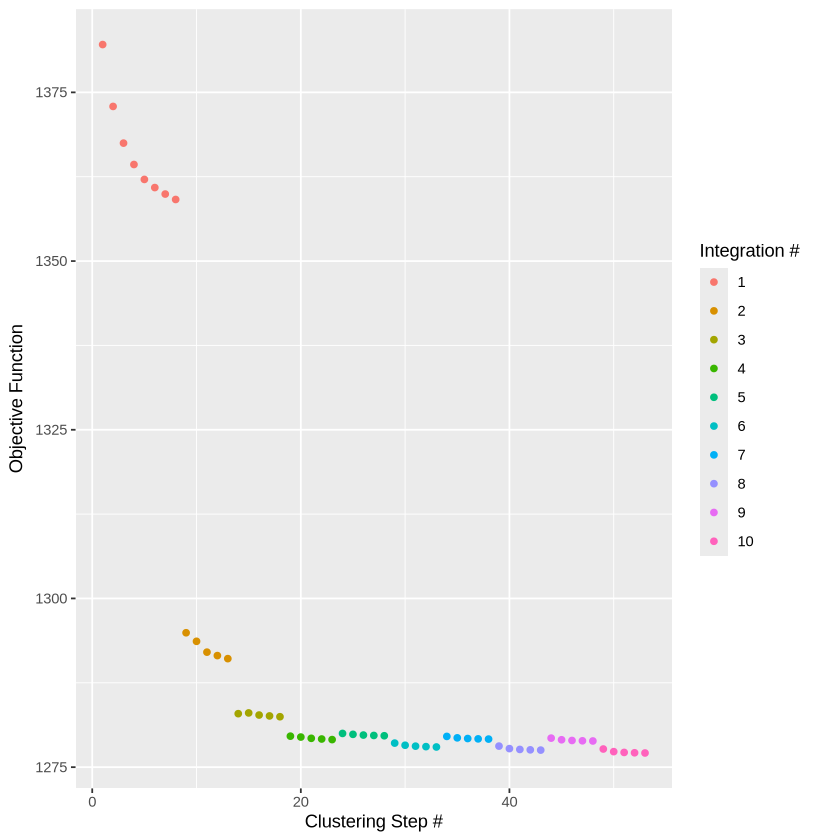

In [43]:
set.seed(1)
plan(multisession, workers=35)
xenium.seurat <- harmony::RunHarmony(xenium.seurat, c("sid", "slideid"), plot_convergence = TRUE, max_iter = 10, reduction.use = "pca",
                 early_stop = F)

# cache

In [ ]:
saveRDS(xenium.seurat, '../data/cache/20260127_xenium_denovo_harm_seurat.RDS')

In [2]:
xenium.seurat <- readRDS('../data/cache/20260127_xenium_denovo_harm_seurat.RDS')

# run Tessera

In [3]:
xenium.seurat[["tessera_xy"]] <- CreateDimReducObject(
  embeddings = as.matrix(xenium.seurat@meta.data[c('x', 'y')] %>% rename('1' = 'x', '2' = 'y')),  # n_cells × 2
  key = "TESSERA_",
  assay = DefaultAssay(xenium.seurat)
)

In [4]:
future::plan(future::multicore)             # Parallelize over multiple samples (if doing multi-sample analysis)

In [5]:
res = GetTiles(
    xenium.seurat,        # Single-cell Seurat object
    'tessera_xy',  # Name of dimesional reduction where x/y coordinates are stored

    embeddings = 'harmony',  # (Optional) Name of dimensional reduction where pre-computed single-cell embeddings are stored
    group.by = 'sid',  # (Optional) Name of meta.data column that provides sample IDs. If missing, treated as a single sample.

    # Additional Tessera algorithm parameters
    dims.use = 1:20,                                   # Choose how many embedding dimensions to use
    prune_thresh_quantile = 0.99, prune_min_cells = 1, # Control pruning of long edges and disconnected cells
    max_npts = 50, min_npts = 5,                       # Control size of Tessera tiles
)
xenium.seurat = res$obj                # Seurat object of single-cells (with cell-to-tile mapping)
xenium.tiles = res$tile_obj      # Seurat object of Tessera tiles

Warning message in GetTiles.Seurat(xenium.seurat, "tessera_xy", embeddings = "harmony", :
“To avoid overwriting existing meta.data variables, tile.id.name is set to tile_id.1”
Warning message in GetTiles.Seurat(xenium.seurat, "tessera_xy", embeddings = "harmony", :
“Adding back 1395 isolated cells that were pruned out”
Warning message:
“No assay specified, setting assay as RNA by default.”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pca to pca_”


In [6]:
dim(Embeddings(xenium.tiles, reduction='pca'))

[1] 65851    40

In [7]:
plan(multisession, workers=1) 
xenium.tiles = RunUMAPCustom(xenium.tiles)

17:14:51 UMAP embedding parameters a = 0.9922 b = 1.112

17:14:51 Read 65851 rows and found 40 numeric columns

17:14:51 Using Annoy for neighbor search, n_neighbors = 30

17:14:51 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:15:00 Writing NN index file to temp file /tmp/Rtmp4ySt5O/file4b91a58c81fb

17:15:00 Searching Annoy index using 48 threads, search_k = 3000

17:15:01 Annoy recall = 100%

17:15:02 Commencing smooth kNN distance calibration using 48 threads
 with target n_neighbors = 30

17:15:05 Initializing from normalized Laplacian + noise (using RSpectra)

17:15:07 Commencing optimization for 200 epochs, with 3062286 positive edges using 48 threads

17:15:07 Using rng type: tausworthe

17:15:10 Optimization finished



In [8]:
set.seed(1)
plan(multisession, workers=1)

#for (r in c(0.001, 0.0015, 0.002, 0.003, 0.005, 0.0075,
#            0.01, 0.015, 0.02, 0.03, 0.05, 0.075,
#            0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5, 7.5)) {
for (r in c(0.5)) {
    suppressWarnings({
        xenium.tiles = FindClusters(
            object = xenium.tiles, algorithm = 4, method = 'igraph',
            resolution = r, graph.name = 'RNA_fgraph'
        )   # leiden
    })
}

cluster_names = grep('RNA_fgraph_res.', colnames(xenium.tiles@meta.data), value = TRUE)

xenium.seurat@meta.data = xenium.seurat@meta.data %>% left_join(
    xenium.tiles@meta.data %>% select(id, cluster_names),
    by = c('tile_id'='id')
    )

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(cluster_names)

  # Now:
  data %>% select(all_of(cluster_names))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


In [433]:
cell_leiden_cluster <- xenium.seurat[[]] %>% 
    left_join(xenium.tiles@meta.data[c('id', 'RNA_fgraph_res.0.5')], by = join_by(tile_id == id)) %>% 
    pull(RNA_fgraph_res.0.5)

xenium.seurat <- AddMetaData(xenium.seurat, cell_leiden_cluster, col.name = 'RNA_fgraph_res.0.5')

## basic QC + visualization

In [1]:
xenium.tiles <- readRDS('../data/cache//xenium_tiles.rds')
xenium.seurat <- readRDS('./xenium_cells_tiled.rds')

In [9]:
tile_counts <- Matrix::readMM('../data/cache/20260201_tessera_tilecounts.mtx')
tile_pca <- read.csv('../data/cache/20260201_tessera_tilepca.csv')
tile_meta <- read.csv('../data/cache/20260201_tessera_tilemeta.csv')

In [10]:
xenium.tiles <- CreateSeuratObject(
    counts=tile_counts, 
    meta=tile_meta
    )

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


In [4]:
DimPlot(xenium.tiles, group.by='RNA_fgraph_res.0.5') + coord_fixed()

Warning message:
“The following requested variables were not found: RNA_fgraph_res.0.5”


ERROR: Error in `[.data.frame`(data, , group): undefined columns selected


In [11]:
samplemeta <- read.csv('../../yakir/samplemeta.csv') %>% 
    mutate(disease = case_when(
        ra == 'True' ~ 'ra', 
        psa == 'True' ~ 'psa', 
        control == 'True' ~ 'control'
        )
          ) %>% 
    select(-c('ra', 'psa', 'control'))

Joining with `by = join_by(sid)`


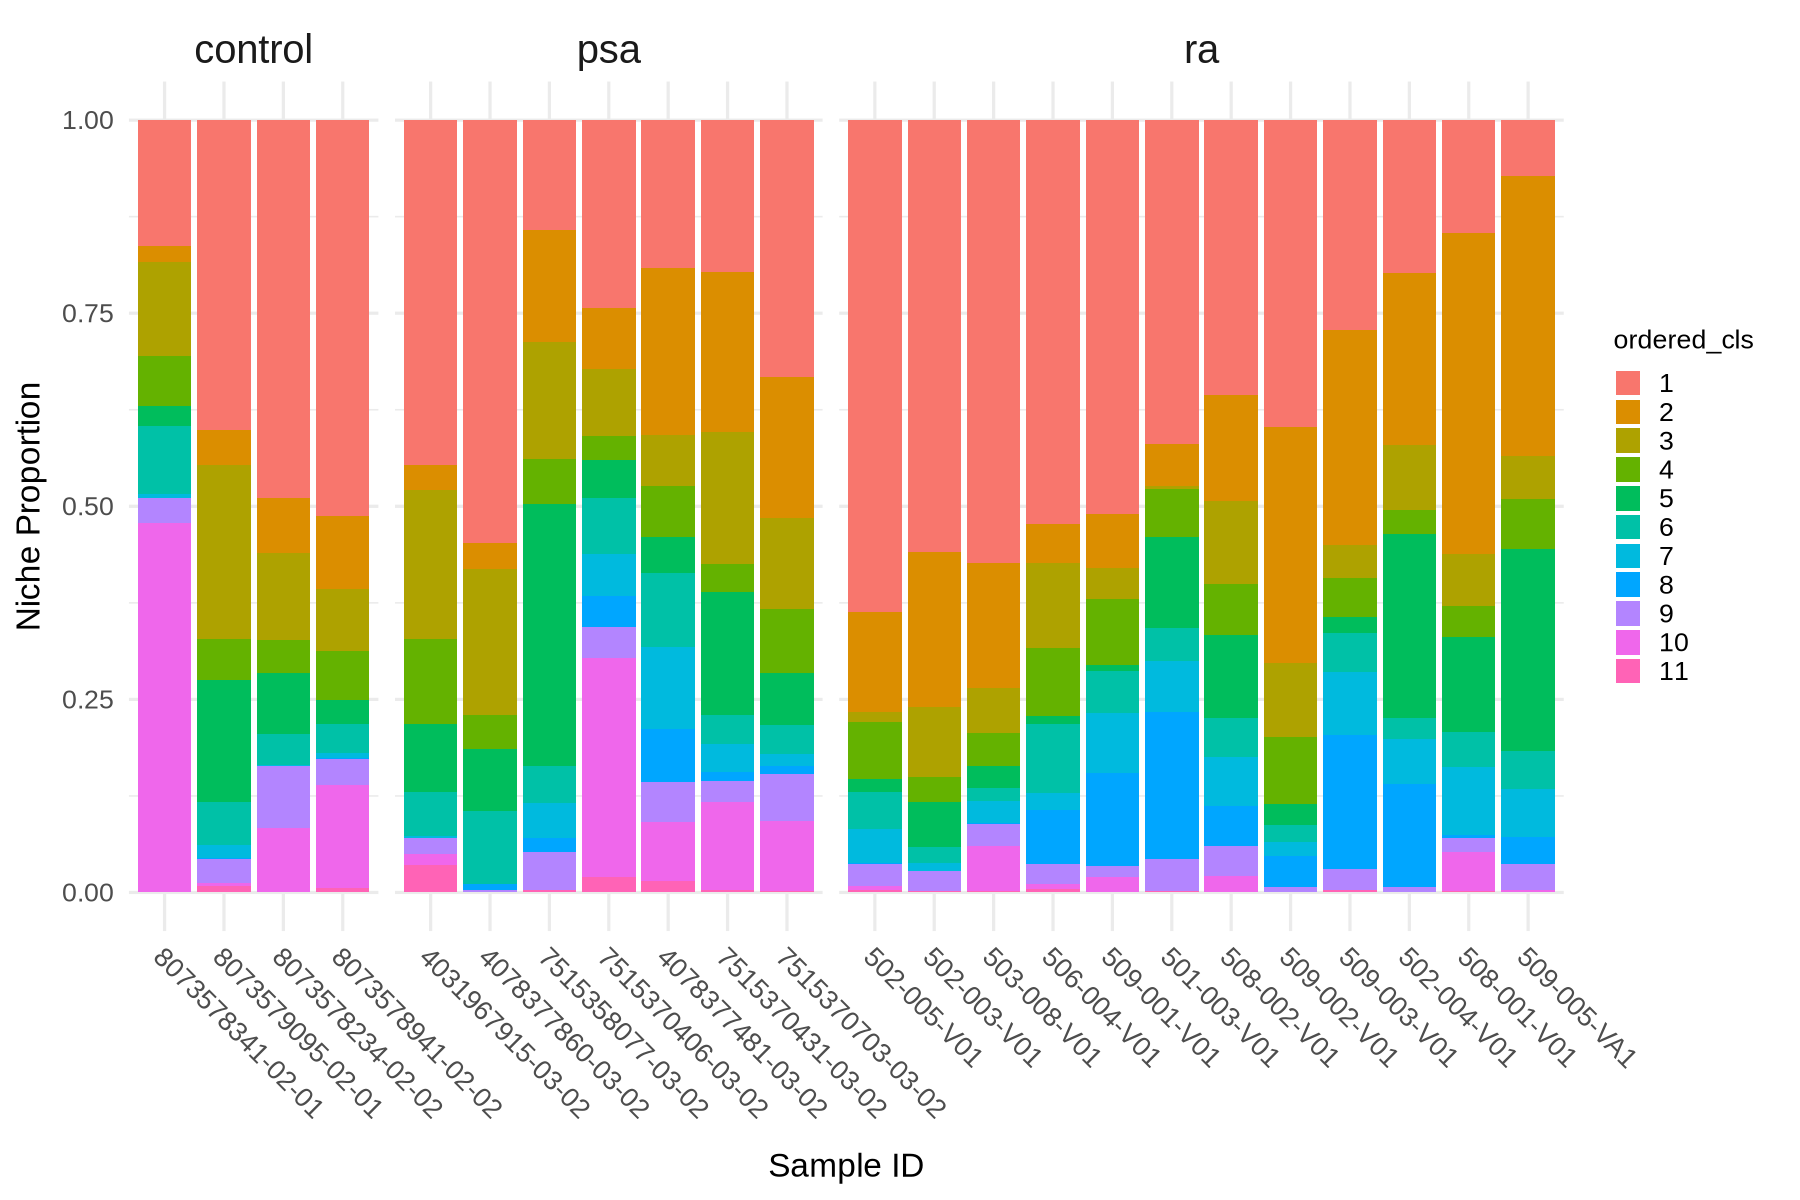

In [44]:
fig.size(10, 15)

df = xenium.tiles[[]] %>% 
    group_by(sid, RNA_fgraph_res.0.5) %>% 
    summarize(niche_abundance = sum(area, na.rm = TRUE), .groups = 'drop_last') %>% 
    mutate(niche_prop = niche_abundance / sum(niche_abundance)) %>% 
    left_join(samplemeta[c('sid', 'disease')])

# 1. Cluster within groups and arrange the dataframe
ordered_df <- df %>%
  group_by(disease) %>%
  group_modify(~ {
    # Pivot and cluster as before
    matrix_subset <- .x %>%
      pivot_wider(id_cols = sid, names_from = RNA_fgraph_res.0.5, 
                  values_from = niche_prop, values_fill = 0) %>%
      column_to_rownames("sid")
    
    hc <- hclust(dist(matrix_subset), method = "ward.D2")
    
    # Arrange the actual data rows based on the cluster order
    ordered_sids <- rownames(matrix_subset)[hc$order]
    .x %>% arrange(match(sid, ordered_sids))
  }) %>%
  ungroup()

# 2. Create a unique identifier and set levels based on appearance
# This is the "Base R" logic: factors follow the order of the rows
ordered_df <- ordered_df %>%
  mutate(temp_id = paste(disease, sid, sep = "_")) %>%
  mutate(temp_id = factor(temp_id, levels = unique(temp_id))) %>% 
  mutate(ordered_cls = factor(RNA_fgraph_res.0.5, levels=sort(unique(RNA_fgraph_res.0.5))))

# 3. Plot using the temporary ID
ggplot(ordered_df, aes(x = temp_id, y = niche_prop, fill = ordered_cls)) +
  geom_bar(stat = "identity", width = 0.9) +
  facet_grid(~disease, scales = "free_x", space = "free_x") +
  # Use the original sid as the label so the "temp_id" is invisible
  scale_x_discrete(labels = function(x) sub("^.*_", "", x)) +
  theme_minimal(base_size=20) +
  labs(x = "Sample ID", y = "Niche Proportion") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
  theme(axis.text.x = element_text(size=16, angle=315, hjust=0), 
              axis.text.y = element_text(size=16), 
              strip.text = element_text(size=24), 
              legend.title = element_text(size=16), 
              legend.text = element_text(size=16)) 

Joining with `by = join_by(sid)`


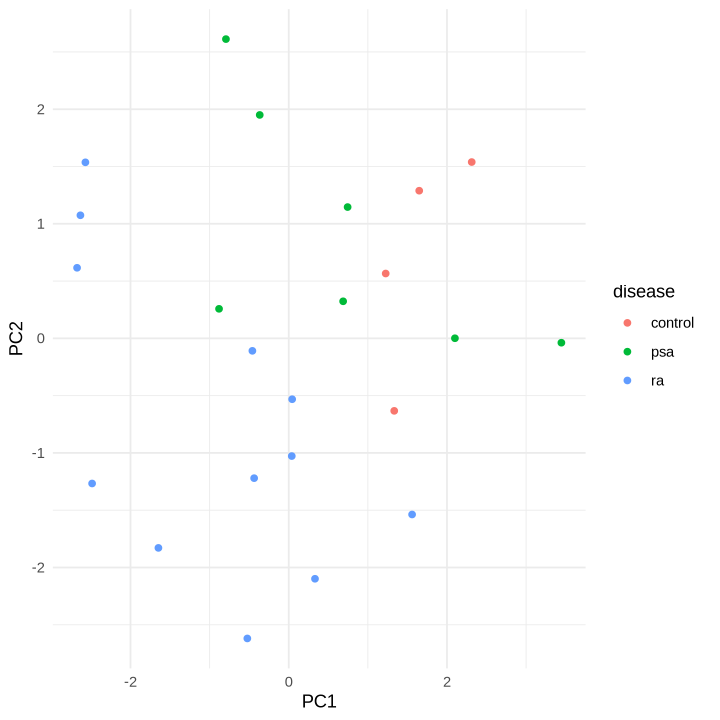

In [46]:
fig.size(6, 6)

dog = ordered_df %>% 
    select(sid, RNA_fgraph_res.0.5, niche_prop) %>% 
    pivot_wider(names_from=RNA_fgraph_res.0.5, values_from=niche_prop, values_fill=0) %>% 
    column_to_rownames('sid') %>%   
    prcomp(center=TRUE, scale.=TRUE)

pca_df = as.data.frame(dog$x) %>% 
    rownames_to_column('sid') %>% 
    left_join(samplemeta %>% 
                  select(sid, disease)) %>% 
    column_to_rownames('sid')

ggplot(pca_df, aes(x=PC1, y=PC2, color=disease)) + 
    geom_point() + 
    theme_minimal()

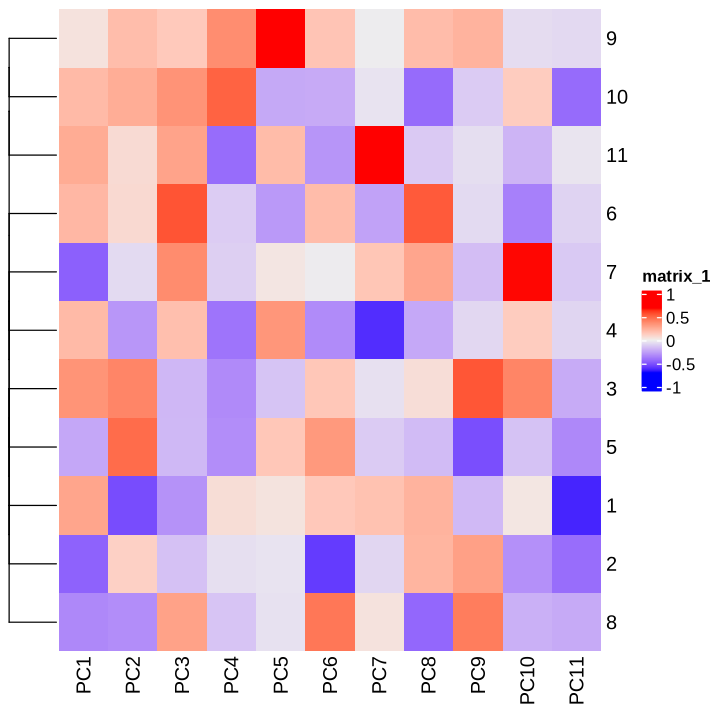

In [47]:
ComplexHeatmap::Heatmap(dog$rotation, cluster_rows=TRUE, cluster_columns=FALSE)

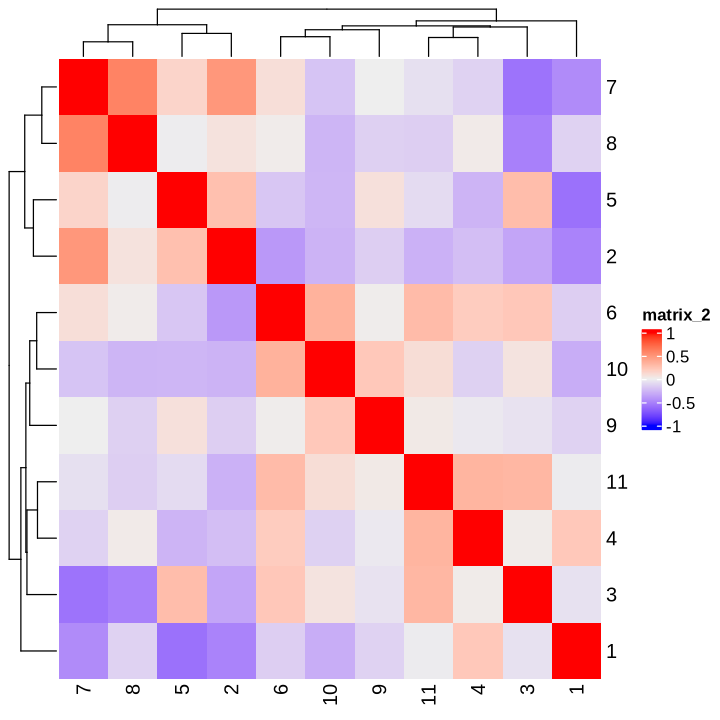

In [48]:
dog_cov <- ordered_df %>% 
    select(sid, RNA_fgraph_res.0.5, niche_prop) %>% 
    pivot_wider(names_from=RNA_fgraph_res.0.5, values_from=niche_prop, values_fill=0) %>% 
    column_to_rownames('sid') 

ComplexHeatmap::Heatmap(cov(dog_cov %>% scale(center=TRUE, scale=TRUE)))

`summarise()` has grouped output by 'sid'. You can override using the `.groups`
argument.
Joining with `by = join_by(sid)`


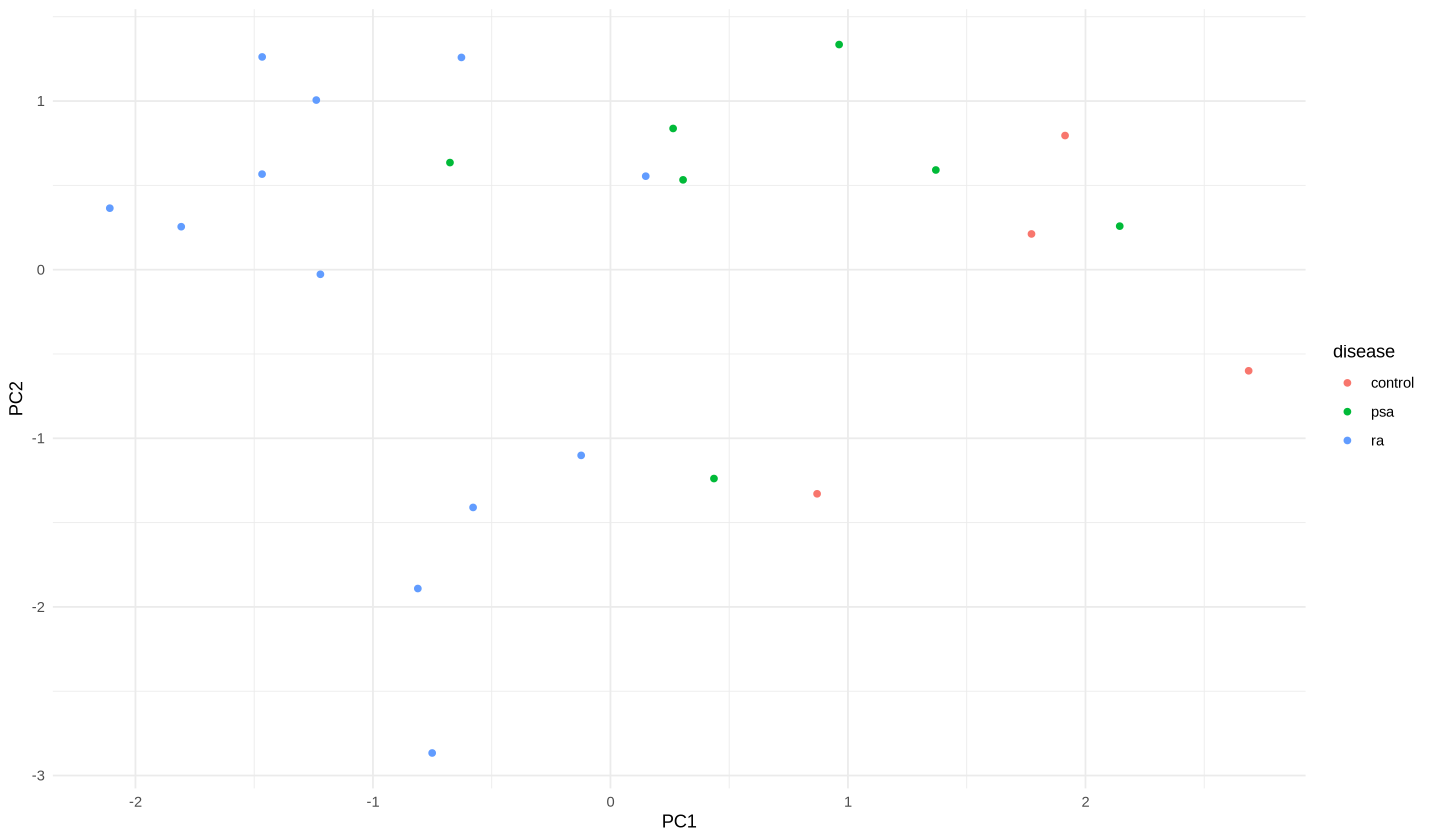

In [340]:
goat = ordered_df %>% 
    select(sid, RNA_fgraph_res.0.5, niche_prop) %>% 
    mutate(metacluster = case_when(
        RNA_fgraph_res.0.5 %in% c('1', '4', '6', '9') ~ 'cluster_1469', 
        RNA_fgraph_res.0.5 %in% c('2', '7', '8') ~ 'cluster_278', 
        RNA_fgraph_res.0.5 %in% c('3', '5', '11') ~ 'cluster_3511', 
        .default = RNA_fgraph_res.0.5
        )
           ) %>% 
    group_by(sid, metacluster) %>% 
    summarize(niche_prop = sum(niche_prop)) %>% 
    pivot_wider(names_from=metacluster, values_from=niche_prop, values_fill=0) %>% 
    column_to_rownames('sid') %>%   
    prcomp(center=TRUE, scale.=TRUE)

goat_pca_df = as.data.frame(goat$x) %>% 
    rownames_to_column('sid') %>% 
    left_join(samplemeta %>% 
                  select(sid, disease)) %>% 
    column_to_rownames('sid')

ggplot(goat_pca_df, aes(x=PC1, y=PC2, color=disease)) + 
    geom_point() + 
    theme_minimal()

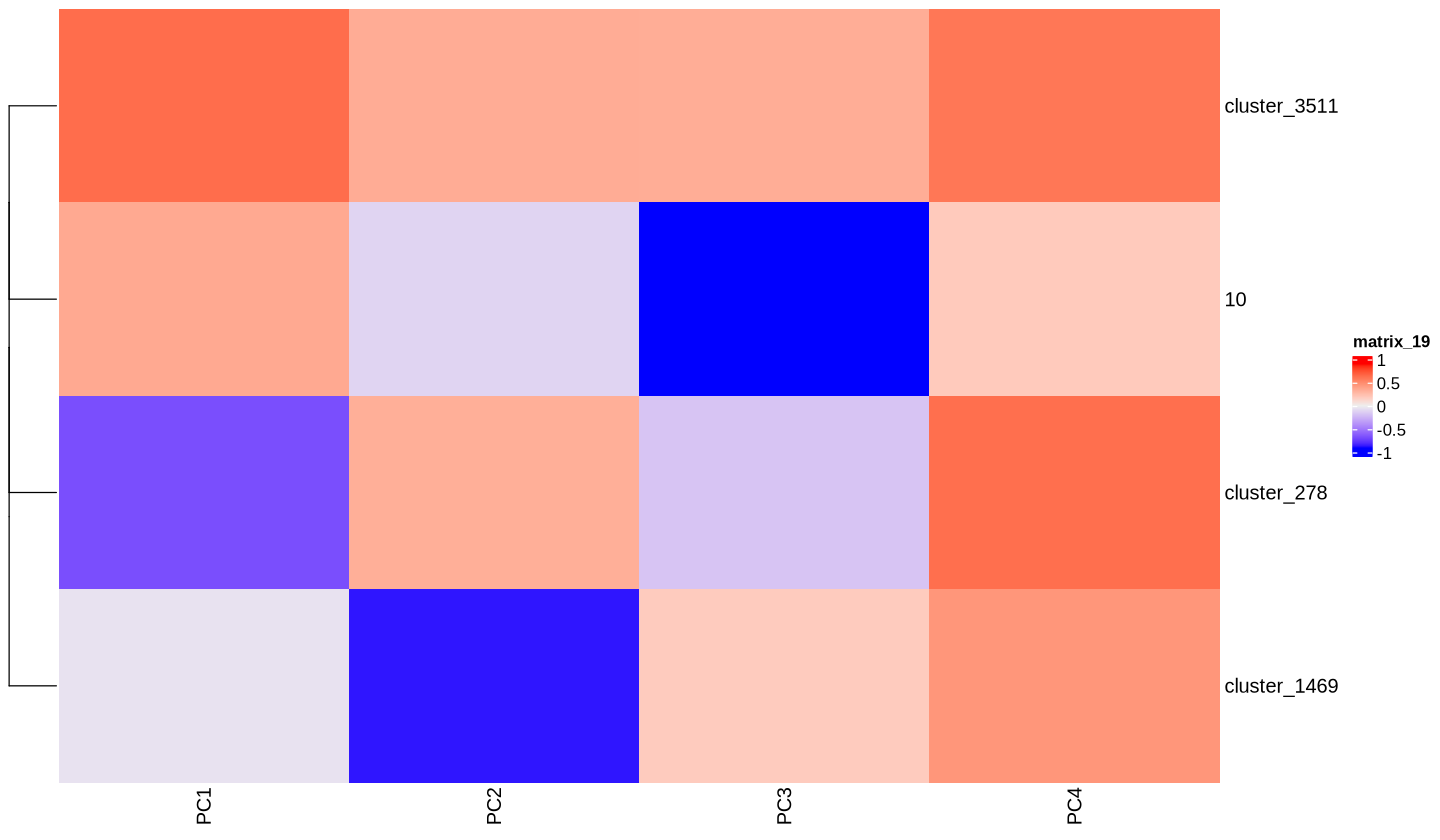

In [341]:
ComplexHeatmap::Heatmap(goat$rotation, cluster_rows=TRUE, cluster_columns=FALSE)

## cache

In [438]:
tile_pca = Embeddings(xenium.tiles, reduction='pca')
tile_counts = LayerData(xenium.tiles, layer='counts')
Matrix::writeMM(tile_counts, '../data/cache/20260201_tessera_tilecounts.mtx')
write.csv(tile_pca, '../data/cache/20260201_tessera_tilepca.csv')
write.csv(xenium.tiles@meta.data %>% select(-shape), '../data/cache/20260201_tessera_tilemeta.csv')

NULL

In [439]:
write.csv(xenium.seurat[[]], '../data/cache/20260201_xeniumcells_tessera_tilelabels.csv')

In [116]:
saveRDS(res$tile_obj, './xenium_tiles.rds')

In [434]:
saveRDS(xenium.seurat, './xenium_cells_tiled.rds')

## visualize tiles in real space 

In [2]:
xenium.tiles <- readRDS('./xenium_tiles.rds')
xenium.seurat <- readRDS('./xenium_cells_tiled.rds')

[1] TRUE

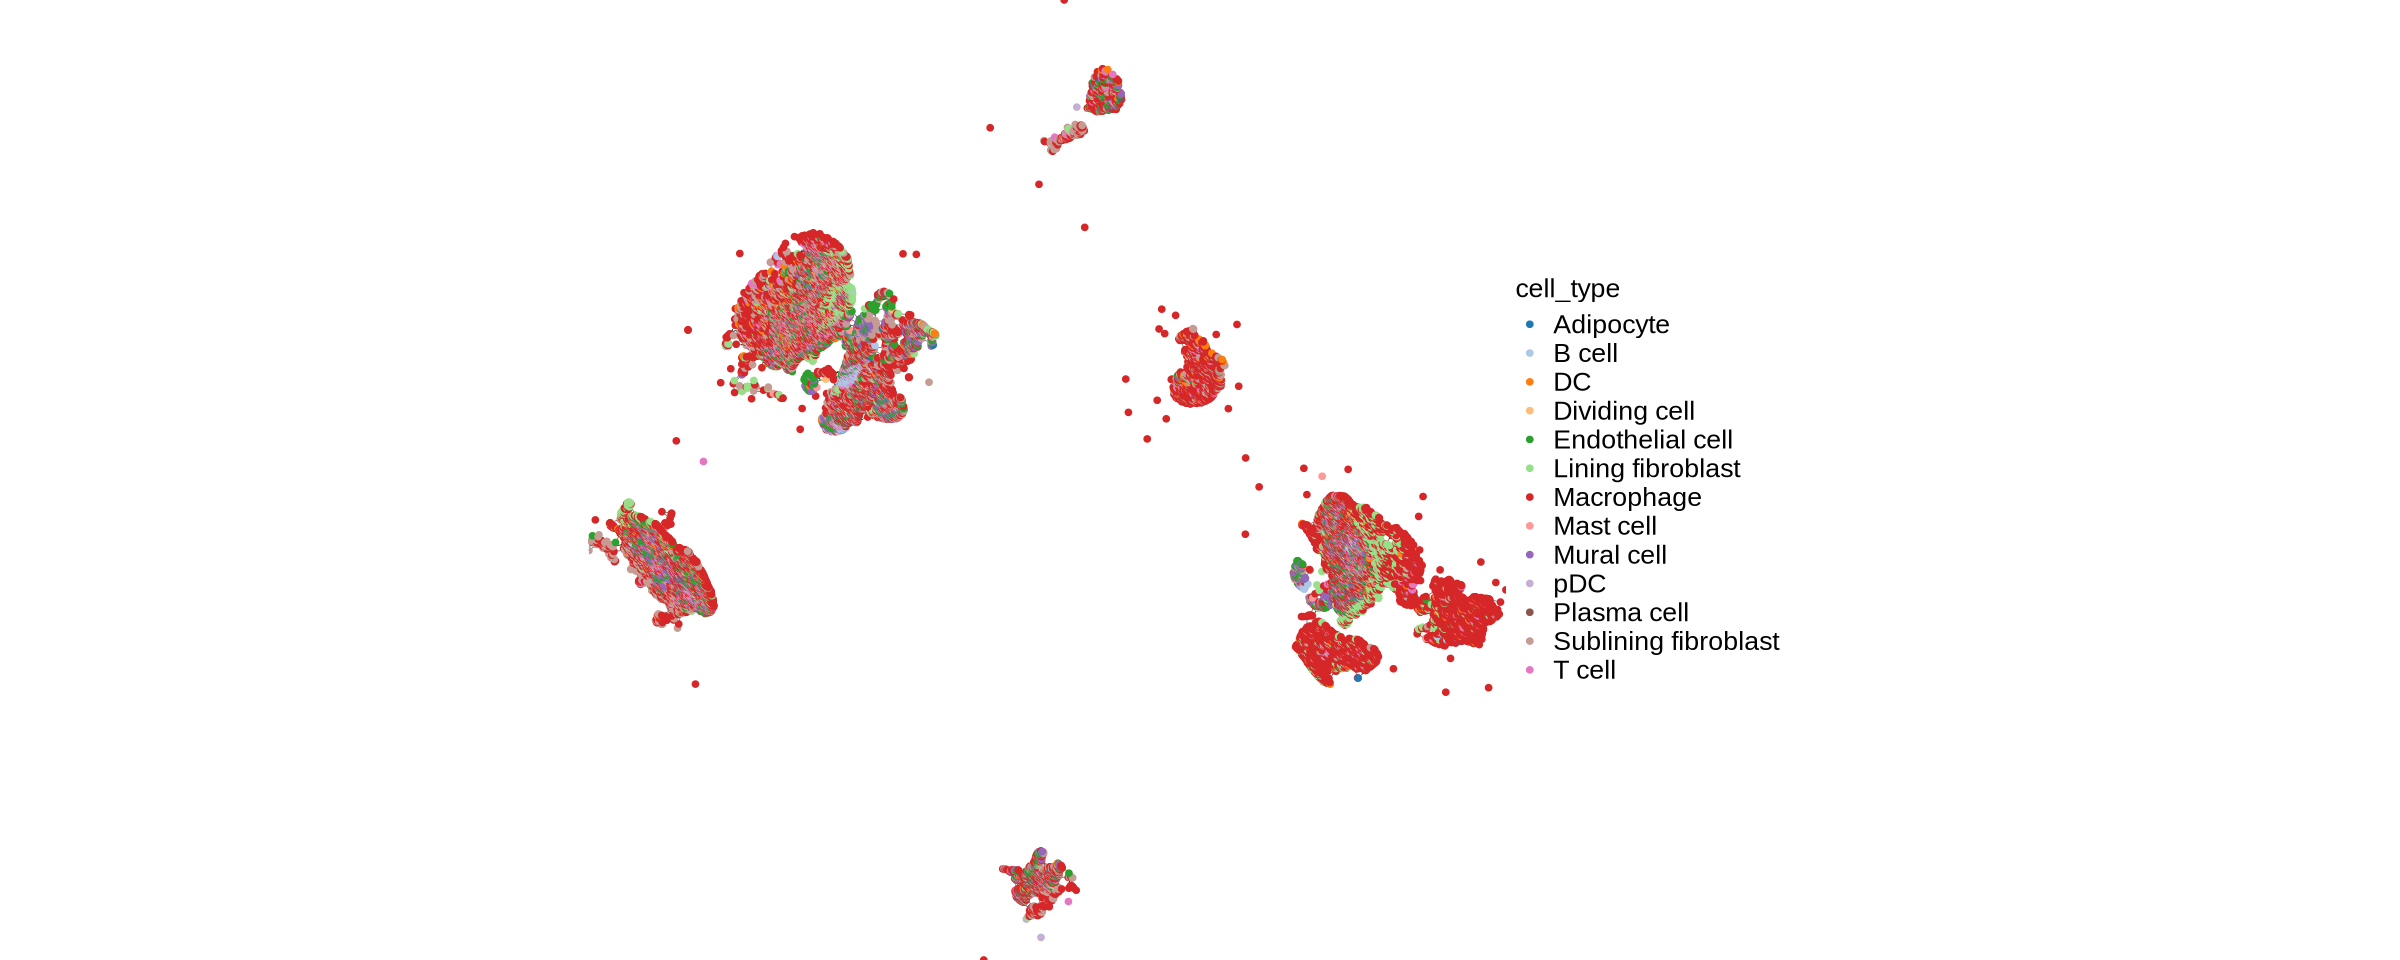

In [31]:
sf::sf_proj_search_paths(paths = "/data/srlab/lsood/miniforge3/envs/tessera_env/share/proj")

p1 = ggplot() + 
    geom_sf(data = xenium.tiles@meta.data %>% filter(sid=='509-005-VA1') %>% st_as_sf(), aes(geometry = shape), fill = NA) + 
    geom_point(data = xenium.seurat[[]] %>% filter(sid=='509-005-VA1'), aes(x, y, color = cell_type)) + 
    scale_color_tableau('Classic 20') + 
    theme_void() + 
    theme(legend.title = element_text(size=16), 
          legend.text = element_text(size=16)) + 
    coord_sf(expand = FALSE, datum = NA) + 
    NULL

p1

[1] TRUE

Warning message:
“Removed 67 rows containing missing values or values outside the scale range
(`geom_point()`).”


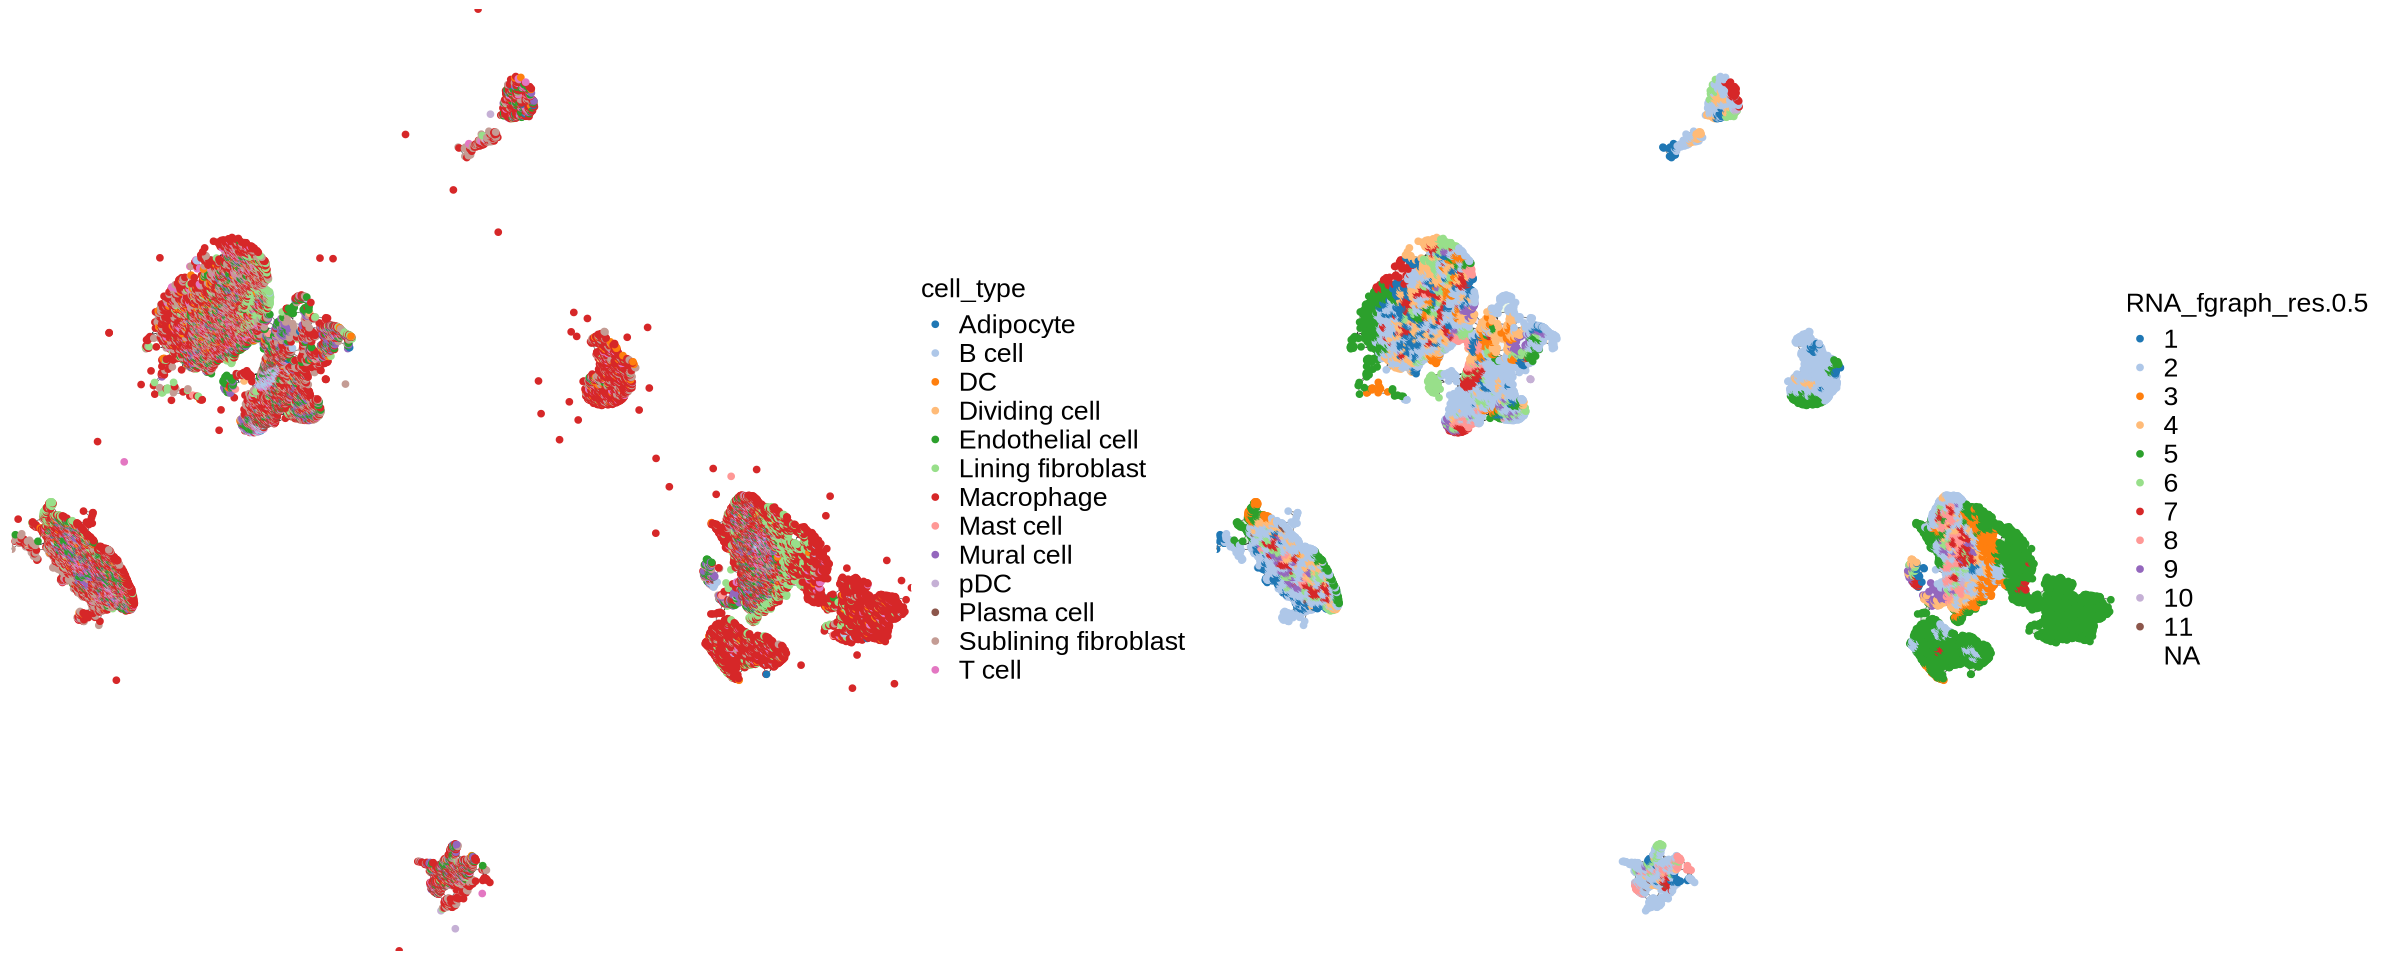

In [33]:
sf::sf_proj_search_paths(paths = "/data/srlab/lsood/miniforge3/envs/tessera_env/share/proj")

p1 = ggplot() + 
    geom_sf(data = xenium.tiles@meta.data %>% filter(sid=='509-005-VA1') %>% st_as_sf(), aes(geometry = shape), fill = NA) + 
    geom_point(data = xenium.seurat[[]] %>% filter(sid=='509-005-VA1'), aes(x, y, color = cell_type)) + 
    scale_color_tableau('Classic 20') + 
    theme_void() + 
    theme(legend.title = element_text(size=16), 
          legend.text = element_text(size=16)) + 
    coord_sf(expand = FALSE) + 
    NULL

p2 = ggplot() + 
    geom_sf(data = xenium.tiles@meta.data %>% filter(sid=='509-005-VA1') %>% st_as_sf(), aes(geometry = shape, fill = RNA_fgraph_res.0.5), alpha = .2) + 
    geom_point(data = xenium.seurat@meta.data %>% filter(sid=='509-005-VA1'), aes(x, y, color = RNA_fgraph_res.0.5)) + 
    scale_color_tableau('Classic 20') + 
    scale_fill_tableau('Classic 20') + 
    theme_void() + 
    guides(fill = 'none') + 
    theme(legend.title = element_text(size=16), 
          legend.text = element_text(size=16)) + 
    coord_sf(expand = FALSE) + 
    NULL
fig.size(8, 20)
p1 | p2

In [234]:
p2_tiles = xenium.tiles@meta.data %>% 
    filter(sid=='508-002-V01') %>% 
    mutate(plot_cluster = ifelse((RNA_fgraph_res.0.5 == 7 | RNA_fgraph_res.0.5 == 8), as.character(RNA_fgraph_res.0.5), NA)) %>% 
    filter(!is.na(plot_cluster))

p2_tiles

,orig.ident,nCount_RNA,nFeature_RNA,id,X,Y,npts,area,perimeter,sid,shape,RNA_fgraph_res.0.5,seurat_clusters,plot_cluster
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<MULTIPOLYGON>,<fct>,<fct>,<chr>
508-002-V01_79,SeuratProject,13992,2680,508-002-V01_79,1076.285,955.3036,43,3183.4992,325.67739,508-002-V01,MULTIPOLYGON (((1044.852 95...,8,8,8
508-002-V01_80,SeuratProject,15319,2731,508-002-V01_80,1148.635,888.7655,45,4915.9336,379.06181,508-002-V01,MULTIPOLYGON (((1151.474 93...,8,8,8
508-002-V01_86,SeuratProject,6027,1920,508-002-V01_86,1111.158,919.8672,14,1407.0826,186.56083,508-002-V01,MULTIPOLYGON (((1100.31 906...,7,7,7
508-002-V01_90,SeuratProject,13271,2621,508-002-V01_90,1221.018,853.7567,45,3637.5372,423.35180,508-002-V01,MULTIPOLYGON (((1256.483 80...,8,8,8
508-002-V01_91,SeuratProject,19223,2824,508-002-V01_91,1068.052,1007.0297,48,3672.6194,353.51438,508-002-V01,MULTIPOLYGON (((1067.074 97...,8,8,8
508-002-V01_92,SeuratProject,14683,2623,508-002-V01_92,1124.193,966.0301,32,2445.4346,309.70253,508-002-V01,MULTIPOLYGON (((1090.954 95...,8,8,8
508-002-V01_95,SeuratProject,13873,2579,508-002-V01_95,1252.657,870.0839,35,3312.0553,407.86893,508-002-V01,MULTIPOLYGON (((1216.712 89...,7,7,7
508-002-V01_96,SeuratProject,17470,2840,508-002-V01_96,1293.512,863.8233,41,3573.1755,506.88935,508-002-V01,MULTIPOLYGON (((1315.66 901...,8,8,8
508-002-V01_97,SeuratProject,13749,2627,508-002-V01_97,1188.990,955.9962,43,7365.4796,473.23659,508-002-V01,MULTIPOLYGON (((1151.474 93...,8,8,8


Warning message:
“Removed 489 rows containing missing values or values outside the scale range
(`geom_point()`).”


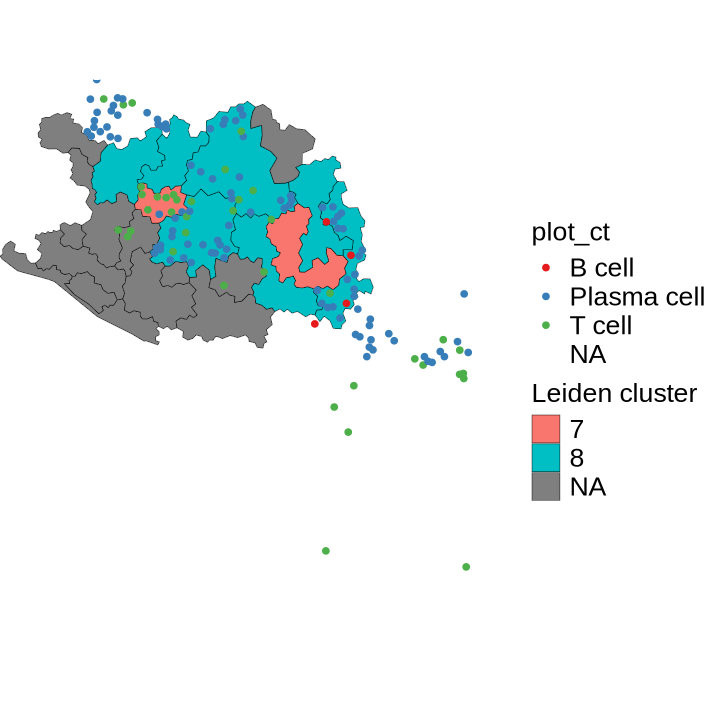

In [231]:
p2_tiles = xenium.tiles@meta.data %>% 
    filter(sid=='508-002-V01') %>% 
    mutate(plot_cluster = ifelse((RNA_fgraph_res.0.5 == 7 | RNA_fgraph_res.0.5 == 8), as.character(RNA_fgraph_res.0.5), NA))

p2_df = p2_tiles %>% 
    filter(sid=='508-002-V01') %>% 
    filter((X > 1000) & (X < 1300) & (Y > 800) & (Y < 1000)) %>% 
    st_as_sf()

p2_points = xenium.seurat[[]] %>% 
    filter(tile_id %in% p2_df$id) %>% 
    mutate(plot_ct = ifelse((cell_type == 'T cell' | cell_type == 'B cell' | cell_type == 'Plasma cell'), as.character(cell_type), NA))

p2 = ggplot() + 
    geom_sf(data = p2_df, aes(geometry = shape, fill = plot_cluster)) + 
    geom_point(data = p2_points, aes(x=x, y=y, color=plot_ct)) + 
    scale_color_brewer(palette='Set1') + 
    theme_void() + 
    labs(fill = 'Leiden cluster') + 
    theme(legend.title = element_text(size=16), 
          legend.text = element_text(size=16)) + 
    coord_sf(expand = FALSE) + 
    NULL

p2

In [304]:
library(presto)

tile.markers <- presto::wilcoxauc(GetAssayData(xenium.tiles, assay='RNA', layer='counts'), Idents(xenium.tiles))

tile.markers %>% 
    group_by(group) %>% 
    filter(padj < 0.05 & auc > 0.5) %>% 
    arrange(group, desc(logFC)) %>% 
    #slice_max(n = 40, order_by = logFC)%>% 
    dplyr::select(feature, group) %>% 
    mutate(row = row_number()) %>% 
    tidyr::pivot_wider(names_from = group, values_from = feature) -> show
show[1:10,]

row,1,10,11,2,3,4,5,6,7,8,9
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,COL6A1,PLIN4,HDC,HLA-DRB1,PRG4,COL4A1,HLA-DRB1,VWF,LTB,XBP1,ACTA2
2,COMP,PLIN1,CTSG,C1QC,MMP3,EPAS1,MMP3,CCL14,MS4A1,MZB1,FLNA
3,CXCL12,ADIPOQ,KIT,C1QA,CLU,COL18A1,S100A4,PLVAP,CD52,DERL3,TPM1
4,COL5A1,PNPLA2,GATA2,CD14,TIMP3,COL4A2,C1QC,POSTN,IL32,SDC1,COL4A1
5,C3,CIDEC,SLC18A2,F13A1,CRTAC1,SHANK3,PRG4,PECAM1,CD3E,EEF1G,COL18A1
6,TNXB,LPL,MS4A2,STAB1,HTRA1,PLVAP,C1QA,SHANK3,EEF1G,PIM2,NOTCH3
7,TNC,AOC3,HPGD,CTSS,S100A4,VWF,S100A10,HSPG2,CXCR4,TENT5C,THY1
8,WISP2,AQP7,IL1RL1,FCGRT,MMP1,ACTA2,CTSS,MYH9,JAK3,HLA-C,MCAM
9,FSTL1,CD36,SIGLEC6,LGMN,S100A10,HSPG2,CLU,ENG,ACAP1,POU2AF1,EPAS1


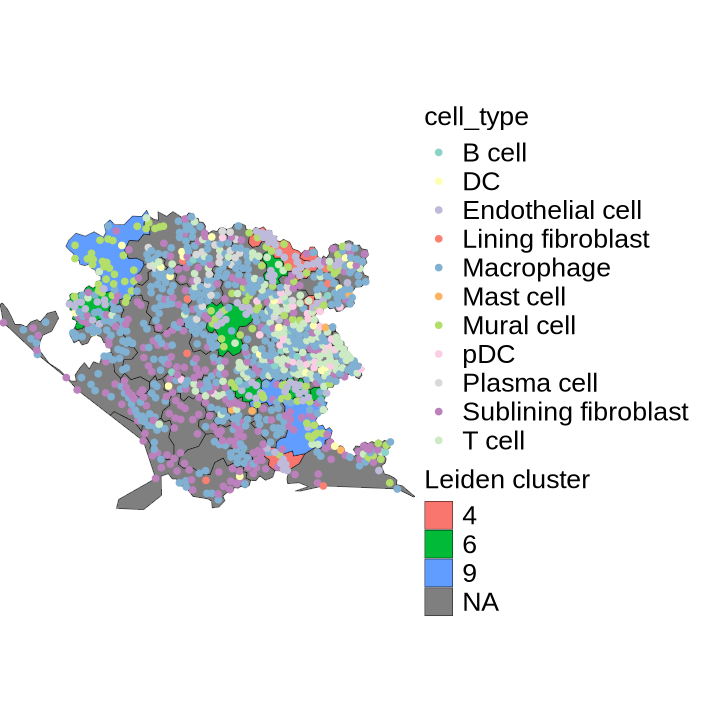

In [105]:
p2_tiles = xenium.tiles@meta.data %>% 
    filter(sid=='509-005-VA1') %>% 
    mutate(plot_cluster = ifelse((RNA_fgraph_res.0.5 %in% c(4, 6, 9)), as.character(RNA_fgraph_res.0.5), NA))

p2_df = p2_tiles %>% 
    filter(sid=='509-005-VA1') %>% 
    filter((X > 700) & (X < 1000) & (Y > 3700) & (Y < 4000)) %>% 
    st_as_sf()

p2_points = xenium.seurat[[]] %>% 
    filter(tile_id %in% p2_df$id) %>% 
    mutate(plot_ct = ifelse(

    #%>% 
    #mutate(plot_ct = ifelse((cell_type == 'Endothelial cell' | cell_type == 'Mural cell'), as.character(cell_type), NA))

p2 = ggplot() + 
    geom_sf(data = p2_df, aes(geometry = shape, fill = plot_cluster)) + 
    geom_point(data = p2_points, aes(x=x, y=y, color=cell_type)) + 
    scale_color_brewer(palette='Set3') + 
    theme_void() + 
    labs(fill = 'Leiden cluster') + 
    theme(legend.title = element_text(size=16), 
          legend.text = element_text(size=16)) + 
    coord_sf(expand = FALSE) + 
    NULL

p2

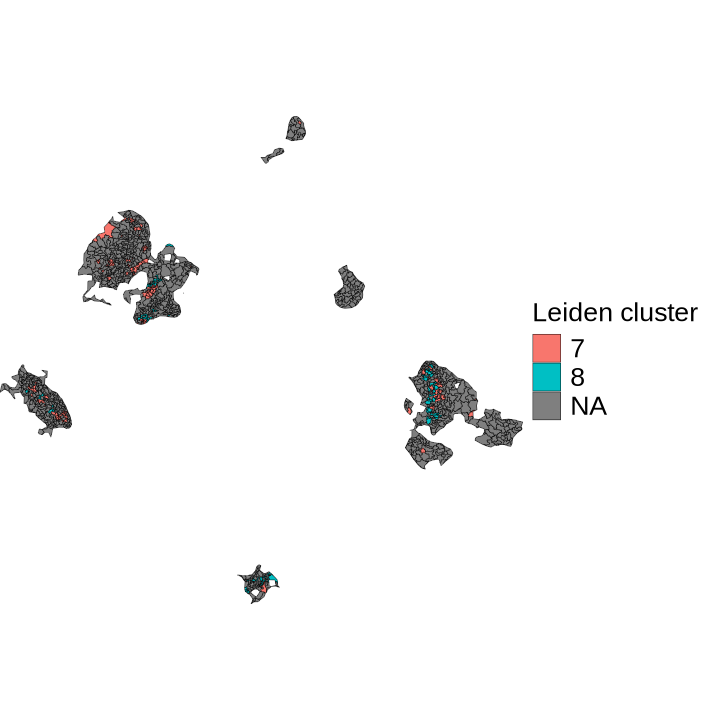

In [57]:
p2_df = xenium.tiles@meta.data %>% 
    filter(sid=='509-005-VA1') %>% 
    mutate(plot_cluster = ifelse((RNA_fgraph_res.0.5 == 7 | RNA_fgraph_res.0.5 == 8), as.character(RNA_fgraph_res.0.5), NA)) %>% 
    st_as_sf()

p2 = ggplot() + 
    geom_sf(data = p2_df, aes(geometry = shape, fill = plot_cluster)) + 
    #scale_fill_tableau('Classic 20') + 
    theme_void() + 
    labs(fill = 'Leiden cluster') + 
    theme(legend.title = element_text(size=16), 
          legend.text = element_text(size=16)) + 
    coord_sf(expand = FALSE) + 
    NULL

p2

Joining with `by = join_by(sid)`


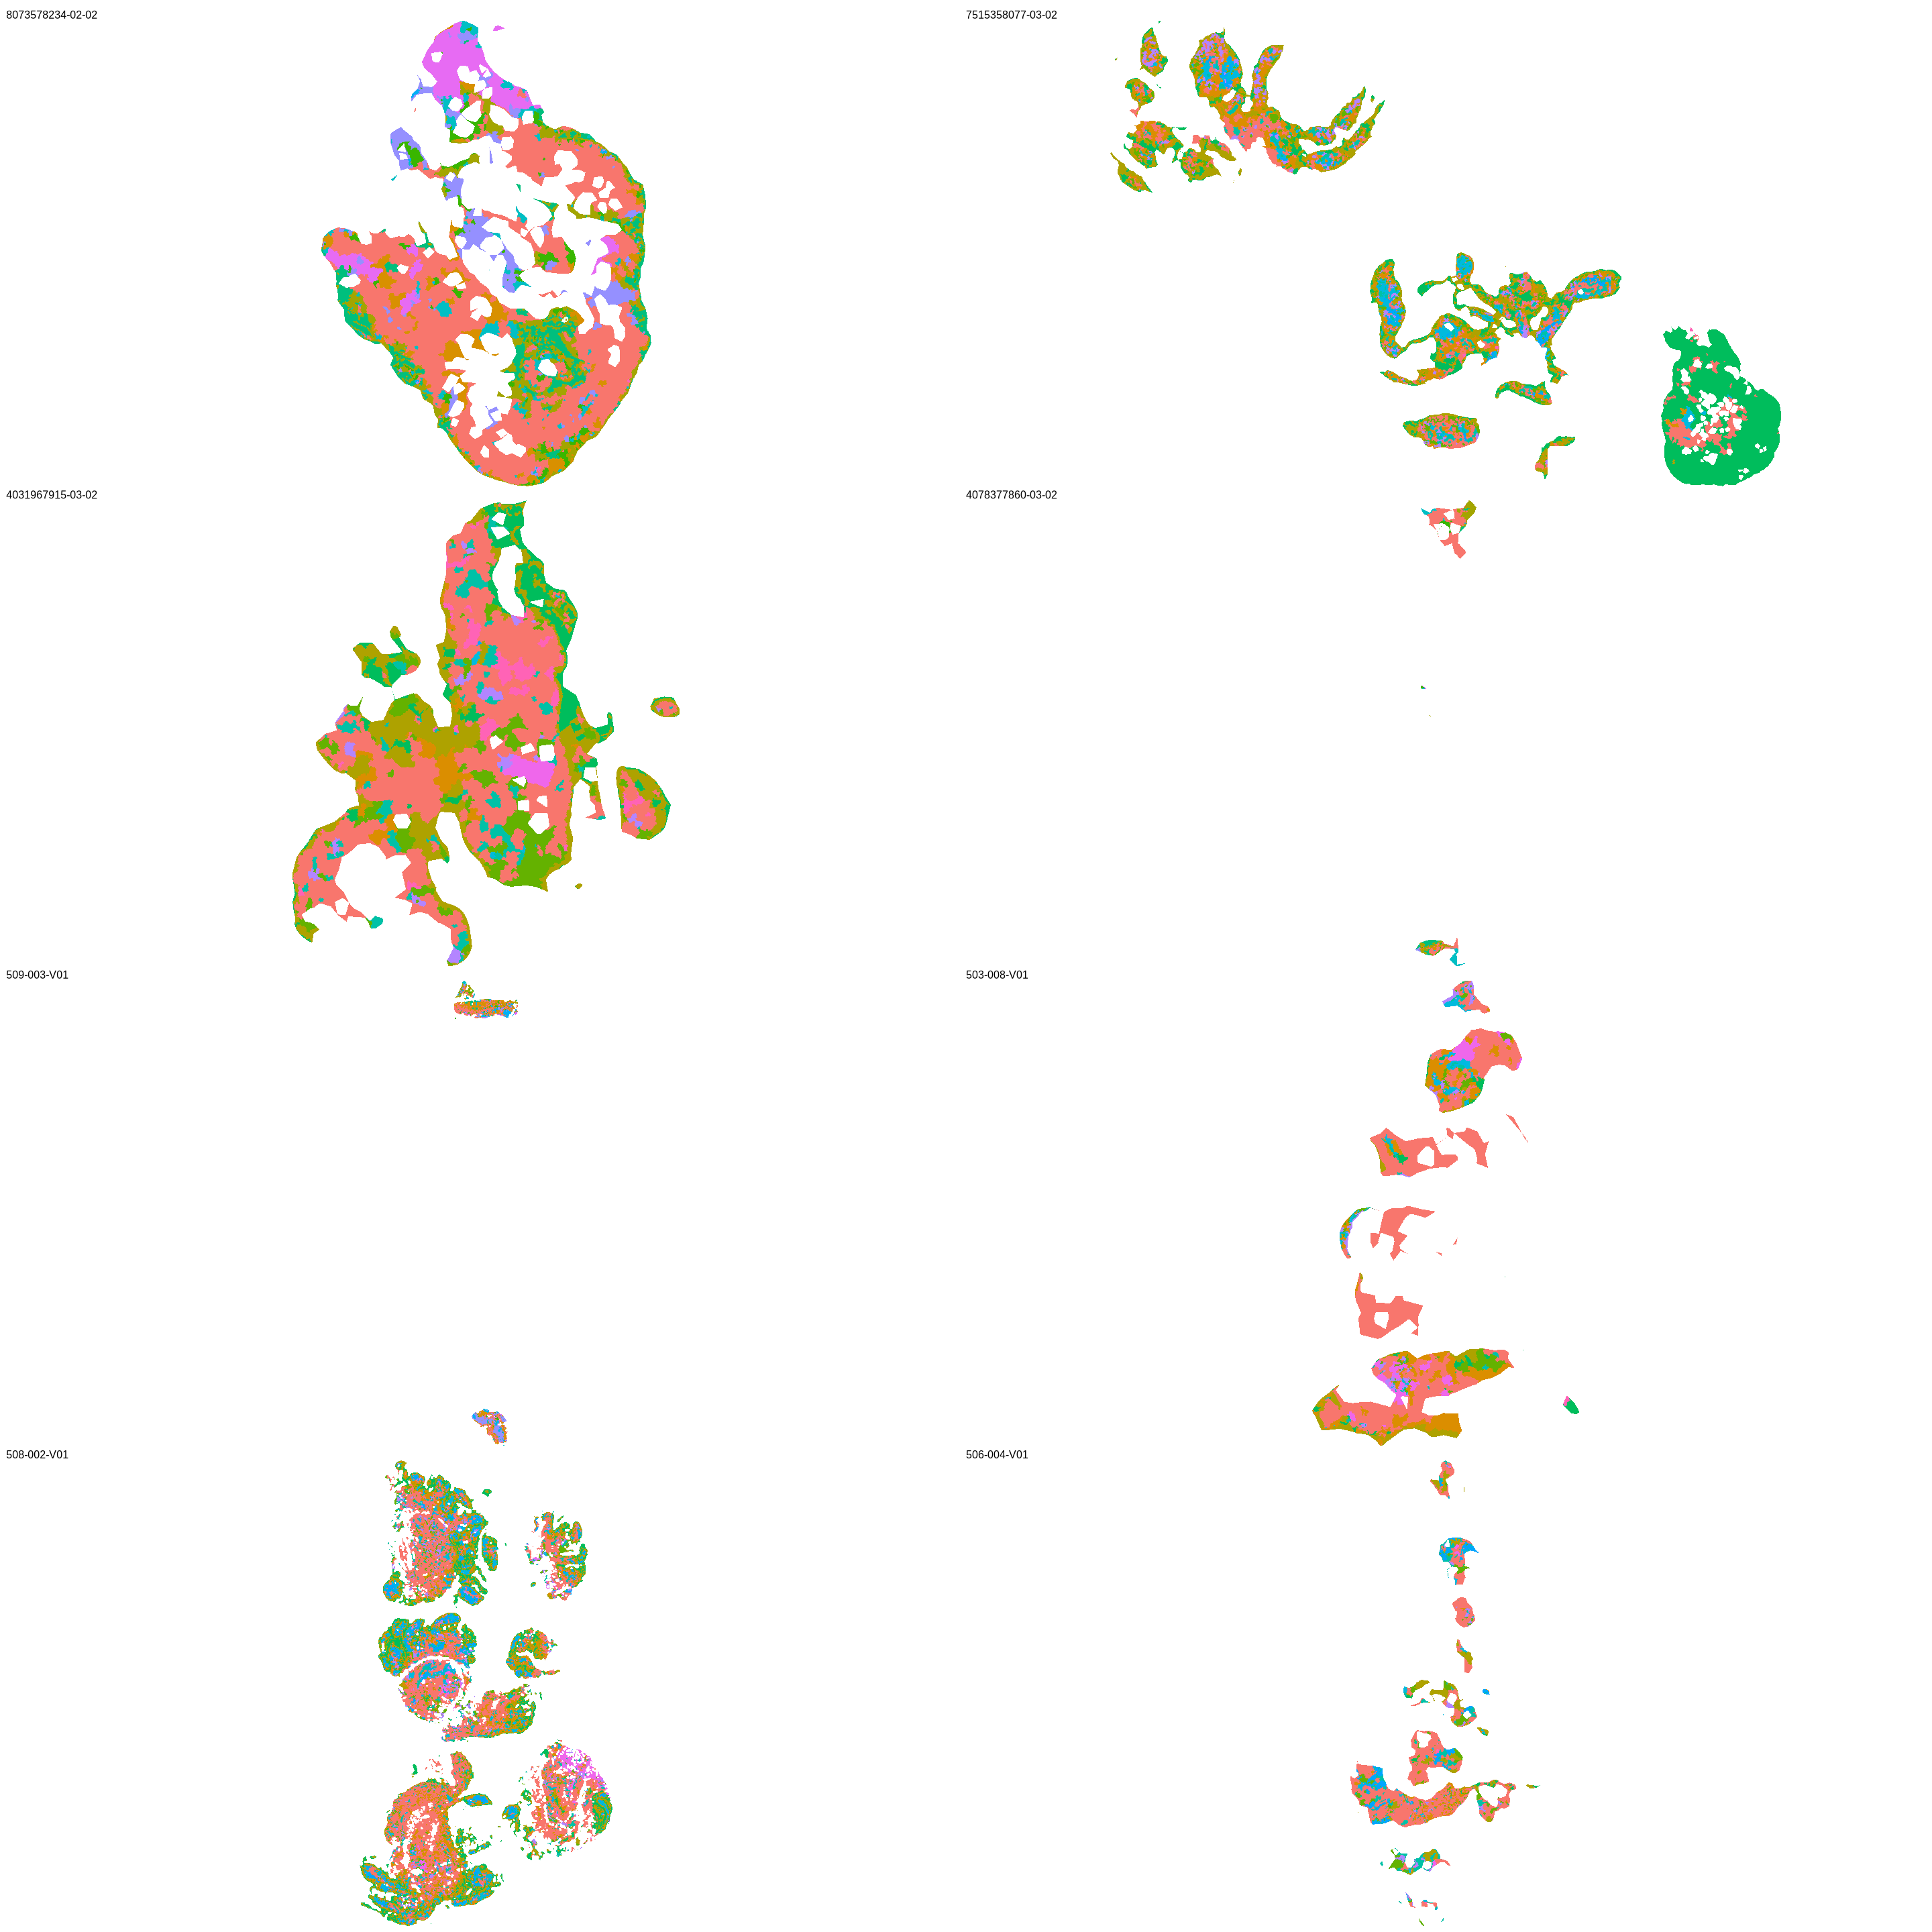

In [107]:
samps = sample(unique(xenium.seurat$sid), 8)
sections_by_cps = xenium.seurat@meta.data %>% as_tibble() %>% select(sid) %>% distinct() %>% filter(sid %in% samps) %>% 
    left_join(samplemeta) %>% arrange(disease) %>% pull(sid) %>% as.character()

fig.size(24, 24)
purrr::map(sections_by_cps, function(section) {
    ggplot() + 
        geom_sf(data = xenium.tiles@meta.data %>% filter(sid==section),
                aes(geometry = shape, fill = RNA_fgraph_res.0.5), linewidth=0) + 
        # geom_point(data = all_dmt_pts,
        #            aes(x=X, y=Y, fill=seurat_clusters),
        #            shape=21, color='black', stroke=0.1) + 
        # geom_scattermore(data = all_dmt_pts,
        #                  aes(X, Y, color=seurat_clusters), pointsize=2.2) +
        theme_void(base_size = 8) + 
        coord_sf(expand = FALSE) + 
        # scale_fill_tableau('Classic 20') + 
        # scale_color_tableau('Classic 20') + 
        #scale_fill_manual(values = palette) + 
        labs(title = stringr::str_wrap(glue('{section}', width=15))) +
        guides(color = 'none', fill = 'none') + 
        NULL
    }) %>% purrr::reduce(`+`) + plot_layout(nrow = 4, widths=rep(1, 2), heights=rep(1, 2))

Warning message:
“Removed 1423 rows containing missing values or values outside the scale range
(`position_quasirandom()`).”


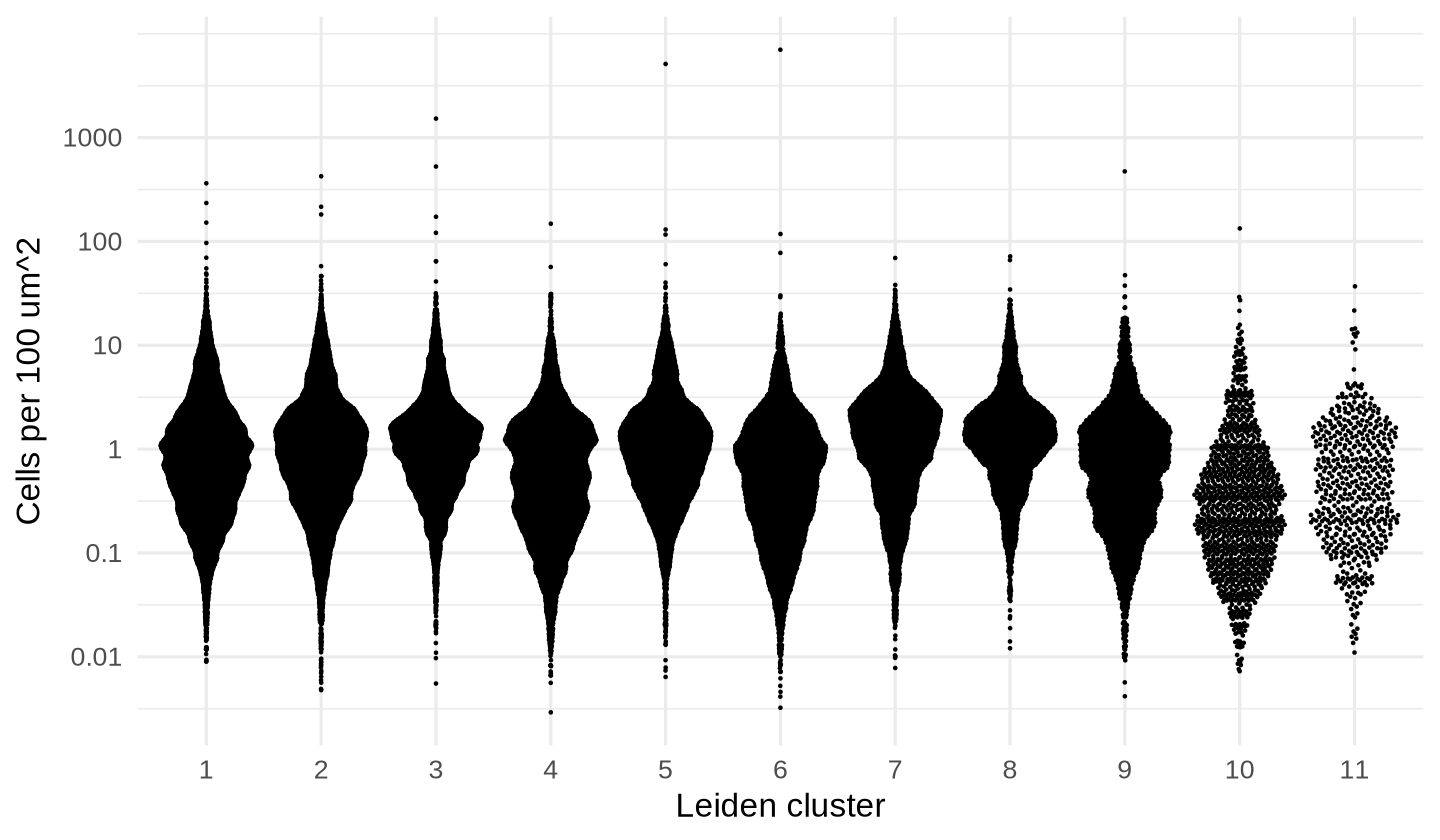

In [12]:
fig.size(7, 12)

xenium.seurat[[]] %>% 
    count(RNA_fgraph_res.0.5, tile_id) %>% 
    left_join(xenium.tiles@meta.data[c('id', 'area')], by = join_by(tile_id == id)) %>% 
    mutate(density = n / area * 100) %>% 
    ggplot(aes(x = RNA_fgraph_res.0.5, y = density)) + 
        geom_quasirandom(size=0.1) + 
        theme_minimal(base_size=20) + 
        scale_y_log10(breaks = c(0.01, 0.1, 1, 10, 100, 1000), 
                      labels = c("0.01", "0.1", "1", "10", "100", "1000")) + 
        labs(x='Leiden cluster', 
             y='Cells per 100 um^2')

`summarise()` has grouped output by 'RNA_fgraph_res.0.5'. You can override
using the `.groups` argument.


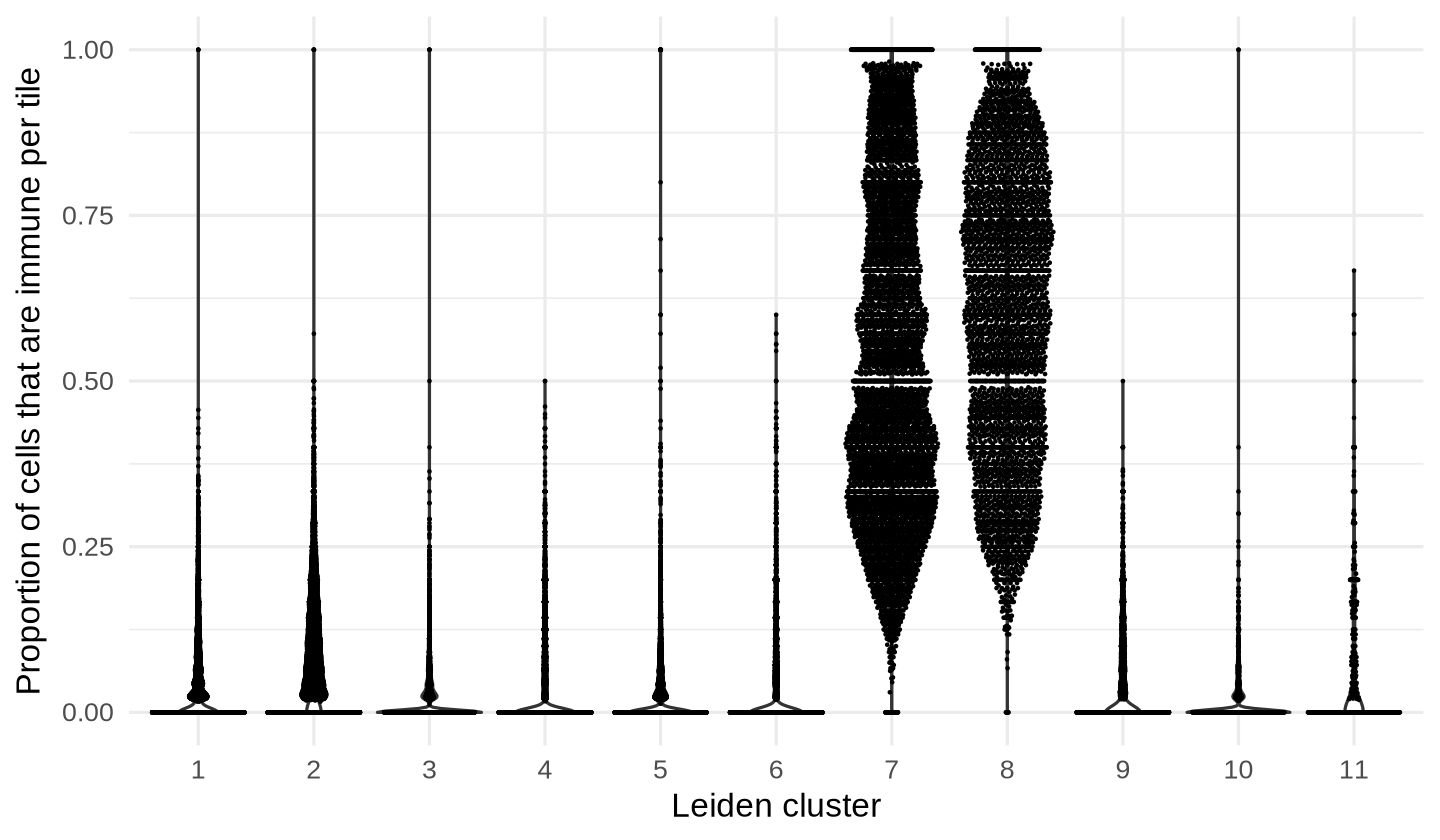

In [9]:
xenium.seurat[[]] %>% 
    group_by(RNA_fgraph_res.0.5, tile_id) %>% 
    summarize(prop_immune = sum(cell_type %in% c("T cell", "B cell", "Plasma cell", "DC", "pDC"))/n()) %>% 
    ggplot(aes(x = RNA_fgraph_res.0.5, y = prop_immune)) + 
        geom_violin() + 
        geom_quasirandom(size=0.1) + 
        theme_minimal(base_size=20) + 
        labs(x='Leiden cluster', 
             y='Proportion of cells that are immune per tile')


In [14]:
Idents(xenium.seurat) <- 'RNA_fgraph_res.0.5'

In [20]:
xenium_t <- subset(
  xenium.seurat,
  subset = cell_type == "T cell"
)

In [24]:
tcell.markers <- presto::wilcoxauc(GetAssayData(xenium_t, assay='RNA', layer='counts'), Idents(xenium_t))

tcell.markers %>% 
    group_by(group) %>% 
    filter(padj < 0.05 & auc > 0.5) %>% 
    arrange(group, desc(logFC)) %>% 
    #slice_max(n = 40, order_by = logFC)%>% 
    dplyr::select(feature, group) %>% 
    mutate(row = row_number()) %>% 
    tidyr::pivot_wider(names_from = group, values_from = feature) -> show
show[1:10,]

row,1,10,11,2,3,4,5,6,7,8,9
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,COL6A1,CXCL12,CLU,HLA-DRB1,CLU,COL6A1,S100A4,GNLY,EEF1G,XBP1,COL6A1
2,CXCL12,SOX2,EEF1G,S100A4,MMP3,S100A4,HLA-DRB1,NKG7,LTB,MZB1,S100A4
3,POSTN,LYVE1,S100A4,C1QC,S100A4,S100A10,S100A10,VWF,HLA-E,HLA-C,THY1
4,COL5A1,PLIN4,CXCL12,CLU,PRG4,POSTN,FLNA,KLF2,CXCR4,CXCR4,MYH9
5,COMP,KLRB1,EEF1B2,S100A10,SOD2,COL4A1,CLU,COL4A1,IL7R,DERL3,ACTA2
6,WISP2,SPTBN1,MCL1,C1QA,HLA-DRB1,GNLY,MMP3,ACTA2,JAK3,SDC1,COL4A1
7,CLU,LPL,CD52,FLNA,S100A10,COL5A1,SPP1,FLNA,CXCL9,TENT5C,EPAS1
8,NBL1,ADIPOQ,PRSS23,ANXA2,TIMP3,THY1,PKM,EPAS1,CD52,PIM2,CCL19
9,MMP14,SFRP1,SOX2,COL6A1,ANXA2,TIMP3,C1QC,THY1,STAT1,CD79A,CFH


## tile proximity

In [196]:
nearby_tiles = xenium.tiles[[]] %>% st_as_sf() 
nearby_tiles = st_touches(nearby_tiles)

In [209]:
nearby_tile_names = nearby_tiles %>%
  map(~ rownames(xenium.tiles[[]])[.x]) %>%
  map_df(~ as.data.frame(t(.x)))

rownames(nearby_tile_names) = rownames(xenium.tiles[[]])

## visualize tiles in UMAP space

# find marker cell types per tile leiden cluster

In [290]:
CellTypeEnrichmentHeatmap = function(
    metadata, group1, group2,
    method = c("log_enrichment", "enrichment", "frac_g1", "frac_g2", "lfc", "logOR"),
    limits = NULL, row_names_colors = NULL, column_names_colors = NULL, col = NULL, return_values = FALSE,
    ...
) { 
    method = method[1]

    metadata[[group1]] = droplevels(metadata[[group1]])
    metadata[[group2]] = droplevels(metadata[[group2]])
    
    values_to_plot = metadata %>% group_by(!!sym(group1), !!sym(group2)) %>% summarize(npts_g1_g2 = as.numeric(n())) %>% ungroup() %>% 
            complete(!!sym(group1), !!sym(group2), fill = list(npts_g1_g2 = 0)) %>% 
        left_join(metadata %>% group_by(!!sym(group1)) %>% summarize(npts_g1 = as.numeric(n())) %>% ungroup() %>% 
            complete(!!sym(group1), fill = list(npts_g1 = 0))) %>% 
        left_join(metadata %>% group_by(!!sym(group2)) %>% summarize(npts_g2 = as.numeric(n())) %>% ungroup() %>% 
            complete(!!sym(group2), fill = list(npts_g2 = 0))) %>% 
        mutate(
            # expected_g1_g2 = npts_g1_g2 / npts_g1 * npts_g1_g2 / npts_g2 * nrow(metadata),
            expected = npts_g1 * npts_g2 / nrow(metadata),
            enrichment = (npts_g1_g2 - expected) / expected,
            lfc = log(npts_g1_g2 / expected),
            log_enrichment = signed_log((npts_g1_g2 - expected) / expected),
            frac_g1 = npts_g1_g2 / npts_g1,
            frac_g2 = npts_g1_g2 / npts_g2, 
            logOR = log(
                ((fish$npts_g1_g2) / (fish$npts_g1 - fish$npts_g1_g2)) / 
                ((fish$npts_g2 - fish$npts_g1_g2) / (dim(xenium.seurat[[]])[1] - fish$npts_g1 - fish$npts_g2 + fish$npts_g1_g2)) 
            ), 
            x = !!sym(method)
            ) %>% 
        select(!!sym(group1), !!sym(group2), x) %>% 
        pivot_wider(names_from = !!sym(group2), values_from = x, values_fill = 0) %>% 
        column_to_rownames(group1) %>% 
        as.matrix()

    if (method == 'lfc') {
        extrema = range(values_to_plot[is.finite(values_to_plot)])
        values_to_plot[is.na(values_to_plot)] = 0
        values_to_plot[values_to_plot == -Inf] = extrema[1]
        values_to_plot[values_to_plot == Inf] = extrema[2]
    }
    stopifnot(all(is.finite(values_to_plot)))
    
    if (is.null(limits)) {
        limits = c(-max(abs(values_to_plot)), max(abs(values_to_plot)))
    }
    if (is.null(col)) {
        col = circlize::colorRamp2(seq(limits[1], limits[2], length = 3), c("blue", "#EEEEEE", "red"))
    }

    if (return_values) {
        return(list(
            ComplexHeatmap::Heatmap(
                values_to_plot, col=col,
                row_names_gp=grid::gpar(col = row_names_colors),
                column_names_gp=grid::gpar(col = column_names_colors),
                ...
            ),
            values_to_plot
        ))
    } else {
        return(ComplexHeatmap::Heatmap(
            values_to_plot, col=col,
            row_names_gp=grid::gpar(col = row_names_colors),
            column_names_gp=grid::gpar(col = column_names_colors),
            ...
        ))
    }
}

signed_log = function(x) {
    out = log1p(abs(x)) * sign(x)
    out[x == 0] = 0
    return(out)
}

`summarise()` has grouped output by 'RNA_fgraph_res.0.5'. You can override
using the `.groups` argument.
Joining with `by = join_by(RNA_fgraph_res.0.5)`
Joining with `by = join_by(cell_type)`


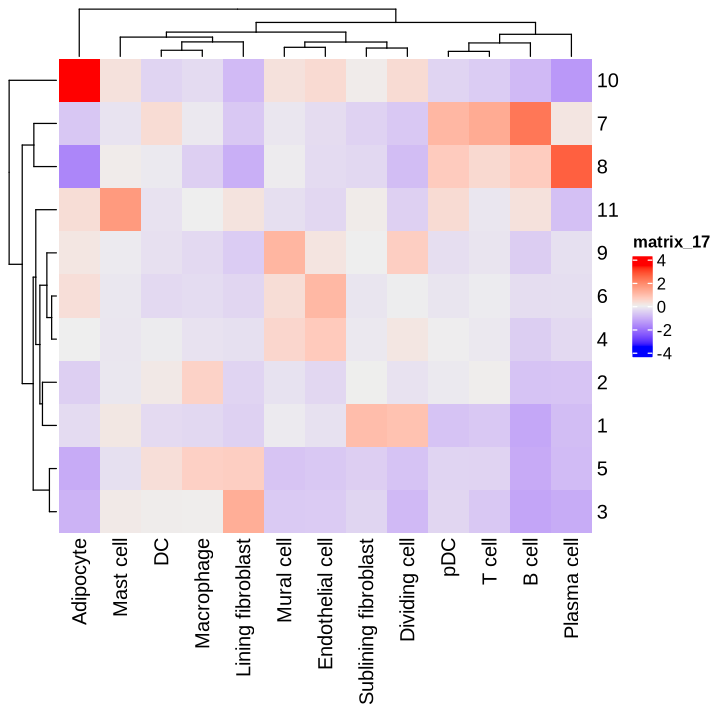

In [291]:
CellTypeEnrichmentHeatmap(
    xenium.seurat@meta.data %>% 
        drop_na('RNA_fgraph_res.0.5') %>% 
        mutate(cell_type = factor(cell_type, levels = unique(cell_type))), 
        'RNA_fgraph_res.0.5', 'cell_type',
    method = "logOR", return_values = FALSE
)


In [369]:
calculate_OR <- function(metadata, col1, col2) {
    metadata = metadata %>% 
        drop_na(col1)
    uA = unique(metadata[[col1]])
    uB = unique(metadata[[col2]])
    combos = expand_grid(uA = uA, uB = uB)
    
    OR = combos %>% 
        mutate(OR = pmap(list(uA, uB), function(A, B) {
            typeA = metadata[[col1]] == A
            typeB = metadata[[col2]] == B
            
            a = sum(typeA & typeB)
            b = sum(typeA & !(typeB))
            c = sum(!(typeA) & typeB)
            d = sum(!(typeA) & !(typeB))
            res = log(a + 1) + log(d + 1) - log(b + 1) - log(c + 1)
            return(res) 
        })) %>% 
    unnest(OR) %>% 
    pivot_wider(names_from = uB, values_from = OR) %>% 
    column_to_rownames('uA')
}

metadata = xenium.seurat[[]] %>% 
    filter(!is.na(RNA_fgraph_res.0.5)) %>% 
    left_join(fine_cellstates, by = join_by(cell == cid)) 

ct_tile_ORs = calculate_OR(metadata, 'RNA_fgraph_res.0.5', 'cluster_name')

In [370]:
clust_result <- pheatmap::pheatmap(ct_tile_ORs, cluster_rows = TRUE, cluster_cols = FALSE, silent = TRUE)
row_order <- clust_result$tree_row$order

# Step 2: Apply row clustering to data
clustered_data <- ct_tile_ORs[row_order, ]

# Step 3: Compute max value row index for each column
max_indices <- apply(clustered_data, 2, which.max)

# Step 4: Sort columns by where their max value appears
col_order <- order(max_indices)
clustered_sorted_data <- clustered_data[, col_order]

fig.size(10, 20)
pheatmap::pheatmap(
    clustered_sorted_data, 
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    angle_col = "315", 
    fontsize = 12,
    color = colorRampPalette(rev(brewer.pal(n = 7, name = "RdBu")))(100), 
    breaks = seq(-4.5, 4.6, length.out = 101)
)

ERROR: Error in hclust(d, method = method): NA/NaN/Inf in foreign function call (arg 10)


`summarise()` has grouped output by 'RNA_fgraph_res.0.5'. You can override
using the `.groups` argument.
Joining with `by = join_by(RNA_fgraph_res.0.5)`
Joining with `by = join_by(cell_type)`


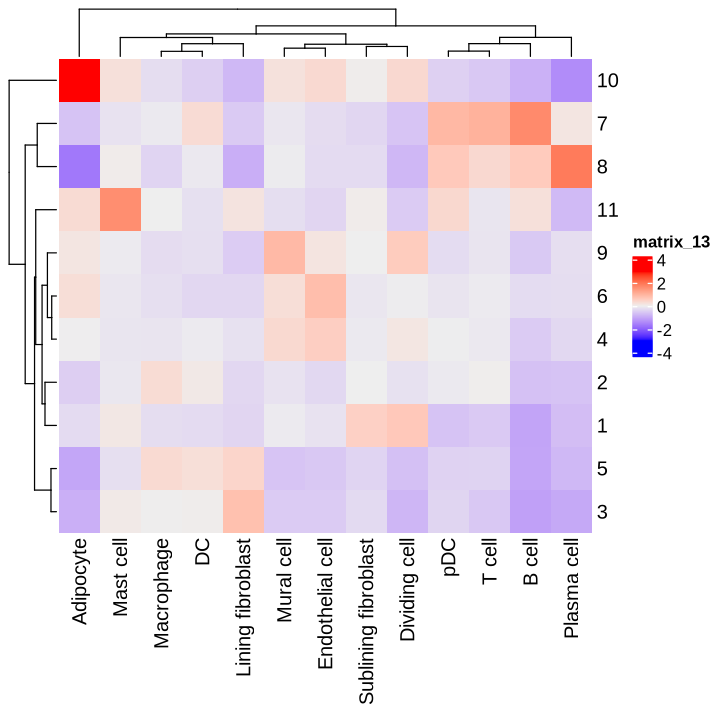

In [241]:
fig.size(6, 6)

library(ComplexHeatmap)
ht = CellTypeEnrichmentHeatmap(
    xenium.seurat@meta.data %>% 
        drop_na('RNA_fgraph_res.0.5') %>% 
        mutate(cell_type = factor(cell_type, levels = unique(cell_type))), 
        'RNA_fgraph_res.0.5', 'cell_type',
    method = "lfc", return_values = FALSE
)

draw(ht)

In [312]:
xenium.seurat[[]] %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,cell,sid,fov,x,y,z,cluster,⋯,ntranscripts,passedqc,logntranscripts,leiden0p5,cell_type,tissue,slideid,tile_id,tile_id.1,RNA_fgraph_res.0.5
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
1,xenium,270,217,CR9384ce767-10,8073578941-02-02,0000,2217.752,170.4108,16.11694,12,⋯,270,True,2.431364,3,Macrophage,Myeloid cell,output-XETG00150__0045146__slidearray0106__20250124__220454,64622,64457,2
2,xenium,153,123,CR9384ce767-20,8073578941-02-02,0000,1509.246,934.8750,16.50619,1,⋯,153,True,2.184691,5,Endothelial cell,Endothelial cell,output-XETG00150__0045146__slidearray0106__20250124__220454,8073578941-02-02_1,8073578941-02-02_1,7
3,xenium,91,81,CR9384ce767-21,8073578941-02-02,0000,1446.126,997.5276,18.37146,2,⋯,91,True,1.959041,3,Macrophage,Myeloid cell,output-XETG00150__0045146__slidearray0106__20250124__220454,8073578941-02-02_1,8073578941-02-02_1,7
4,xenium,106,76,CR9384ce767-23,8073578941-02-02,0000,1528.387,916.4974,19.98814,10,⋯,106,True,2.025306,1,Lining fibroblast,Stromal cell,output-XETG00150__0045146__slidearray0106__20250124__220454,8073578941-02-02_2,8073578941-02-02_2,5
5,xenium,448,311,CR9384ce767-26,8073578941-02-02,0000,1524.729,921.1489,18.78891,12,⋯,448,True,2.651278,2,Macrophage,Myeloid cell,output-XETG00150__0045146__slidearray0106__20250124__220454,8073578941-02-02_2,8073578941-02-02_2,5
6,xenium,148,131,CR9384ce767-32,8073578941-02-02,0000,1458.087,993.4182,20.36641,2,⋯,148,True,2.170262,3,Macrophage,Myeloid cell,output-XETG00150__0045146__slidearray0106__20250124__220454,8073578941-02-02_1,8073578941-02-02_1,7


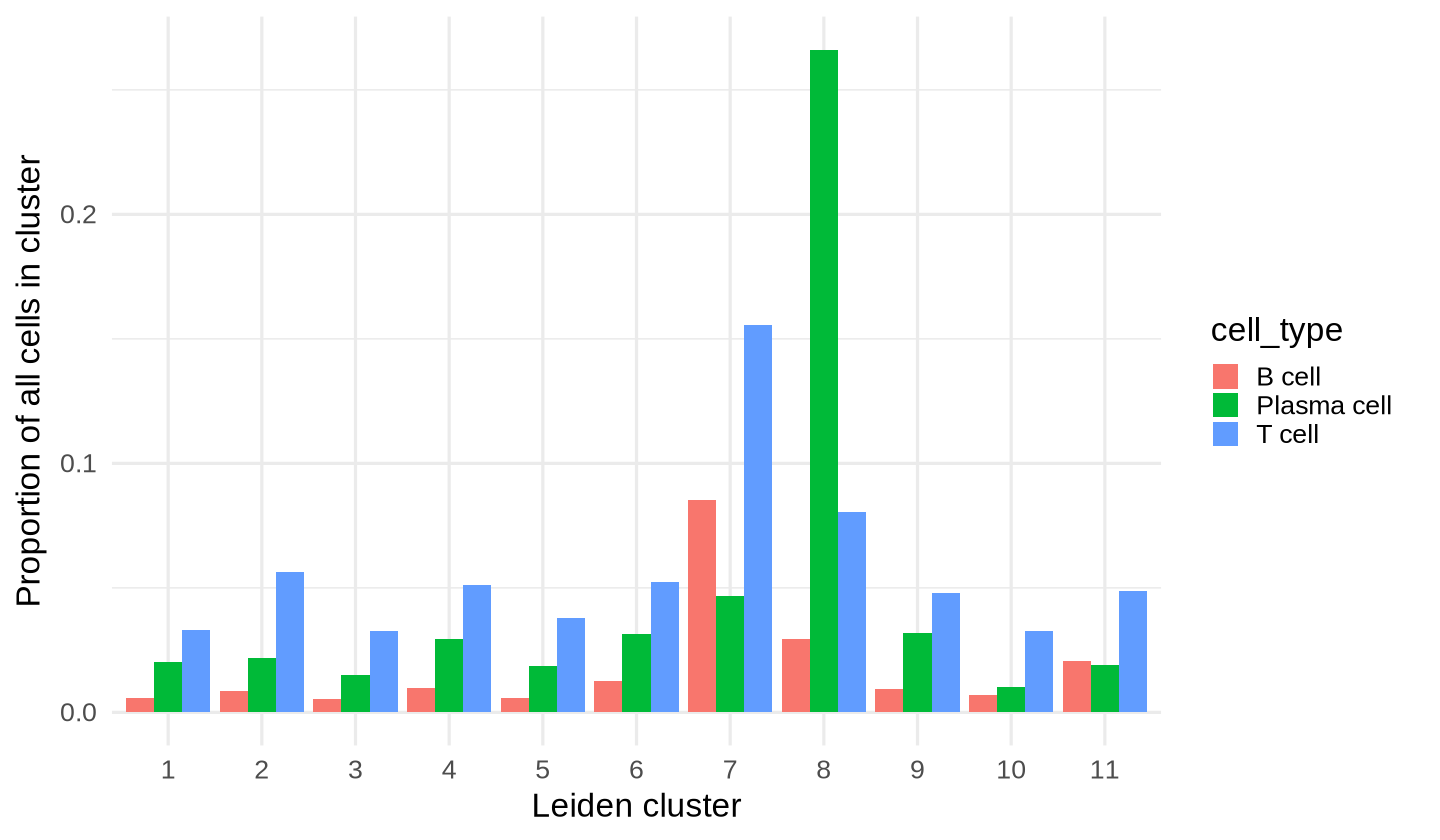

In [333]:
fig.size(7, 12)
xenium.seurat[[]] %>% 
    filter(!is.na(RNA_fgraph_res.0.5)) %>% 
    count(RNA_fgraph_res.0.5, cell_type) %>% 
    group_by(RNA_fgraph_res.0.5) %>% 
    mutate(prop = n / sum(n)) %>% 
    filter(cell_type %in% c("B cell", "T cell", "Plasma cell")) %>% 
    ggplot(aes(x = RNA_fgraph_res.0.5, y = prop, fill = cell_type)) + 
        geom_col(position='dodge') + 
        theme_minimal(base_size = 20) + 
        labs(x = 'Leiden cluster', y = 'Proportion of all cells in cluster')

In [362]:
xenium.seurat[[]] %>% 
    filter(!is.na(RNA_fgraph_res.0.5)) %>% 
    left_join(fine_cellstates, by = join_by(cell == cid)) %>% 
    #filter(!is.na(cluster_name)) %>% 
    count(RNA_fgraph_res.0.5, cluster_name) %>% 
    group_by(RNA_fgraph_res.0.5) %>% 
    mutate(prop = n / sum(n)) %>% 
    #filter(cell_type %in% c("B cell", "T cell", "Plasma cell")) %>% 
    filter(!is.na(cluster_name))

RNA_fgraph_res.0.5,cluster_name,n,prop
<fct>,<chr>,<int>,<dbl>
1,T-0: CD4+ IL7R+ memory,1343,0.0039957751
1,T-10: CD4+ OX40+NR3C1+,140,0.0004165365
1,T-11: CD4+ CD146+ memory,155,0.0004611654
1,T-12: CD4+ GNLY+,112,0.0003332292
1,T-13: CD8+ GZMK/B+ memory,1174,0.0034929561
1,T-14: CD8+ GZMK+ memory,901,0.0026807099
1,T-15: CD8+ GZMB+ TEMRA,318,0.0009461329
1,T-16: CD8+ CD45ROlow/naive,411,0.0012228322
1,T-17: CD8+ activated/NK-like,55,0.0001636393


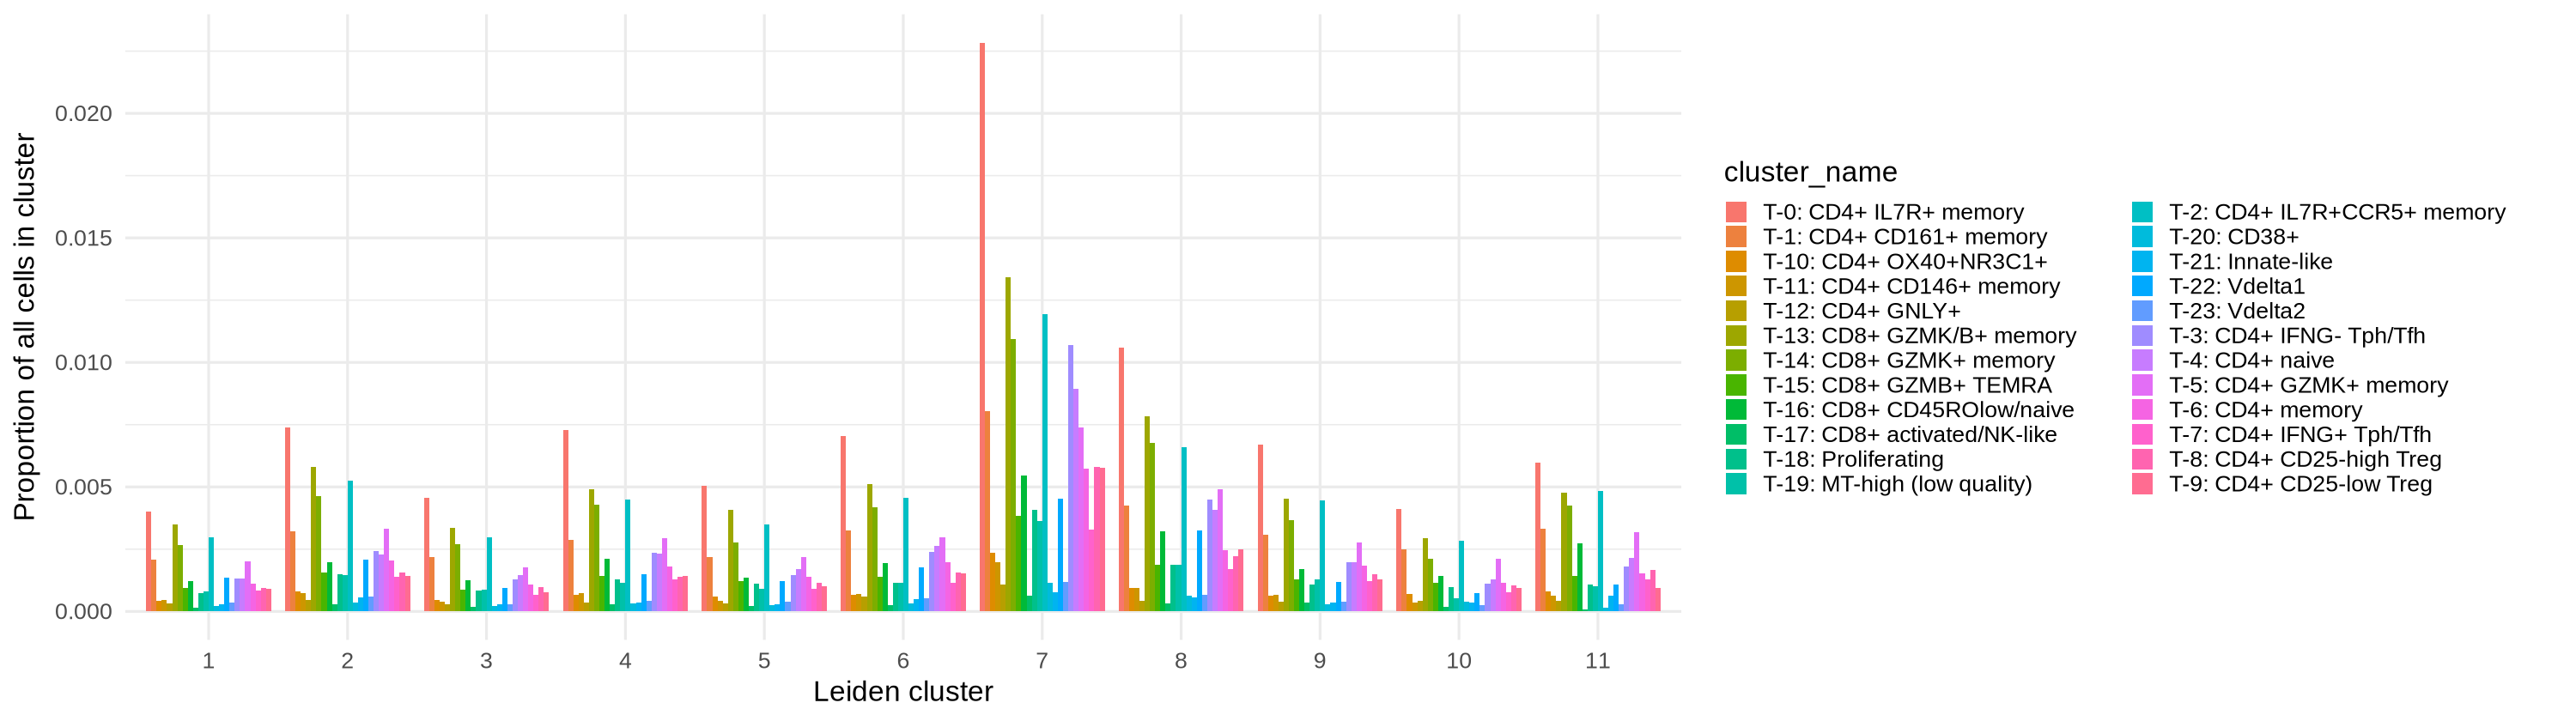

In [358]:
fine_cellstates <- read_csv('../data/cache/Tcell_states.csv', show_col_types = FALSE) %>% 
    filter(!grepl("BRI", cid))

fig.size(7, 25)
xenium.seurat[[]] %>% 
    filter(!is.na(RNA_fgraph_res.0.5)) %>% 
    left_join(fine_cellstates, by = join_by(cell == cid)) %>% 
    #filter(!is.na(cluster_name)) %>% 
    count(RNA_fgraph_res.0.5, cluster_name) %>% 
    group_by(RNA_fgraph_res.0.5) %>% 
    mutate(prop = n / sum(n)) %>% 
    #filter(cell_type %in% c("B cell", "T cell", "Plasma cell")) %>% 
    filter(!is.na(cluster_name)) %>% 
    ggplot(aes(x = RNA_fgraph_res.0.5, y = prop, fill = cluster_name)) + 
        geom_col(position='dodge') + 
        theme_minimal(base_size = 20) + 
        labs(x = 'Leiden cluster', y = 'Proportion of all cells in cluster')

In [ ]:
xenium.seurat[[]] %>% 
    filter(!is.na(RNA_fgraph_res.0.5)) %>% 
    count(RNA_fgraph_res.0.5, cell_type) %>% 
    group_by(RNA_fgraph_res.0.5) %>% 
    mutate(prop = n / sum(n)) %>% 
    filter(cell_type %in% c("B cell", "T cell", "Plasma cell")) %>% 
    ggplot(aes(x = RNA_fgraph_res.0.5, y = prop, fill = cell_type)) + 
        geom_col(position='dodge') + 
        theme_minimal(base_size = 20) + 
        labs(x = 'Leiden cluster', y = 'Proportion of all cells in cluster')

## leiden0.5

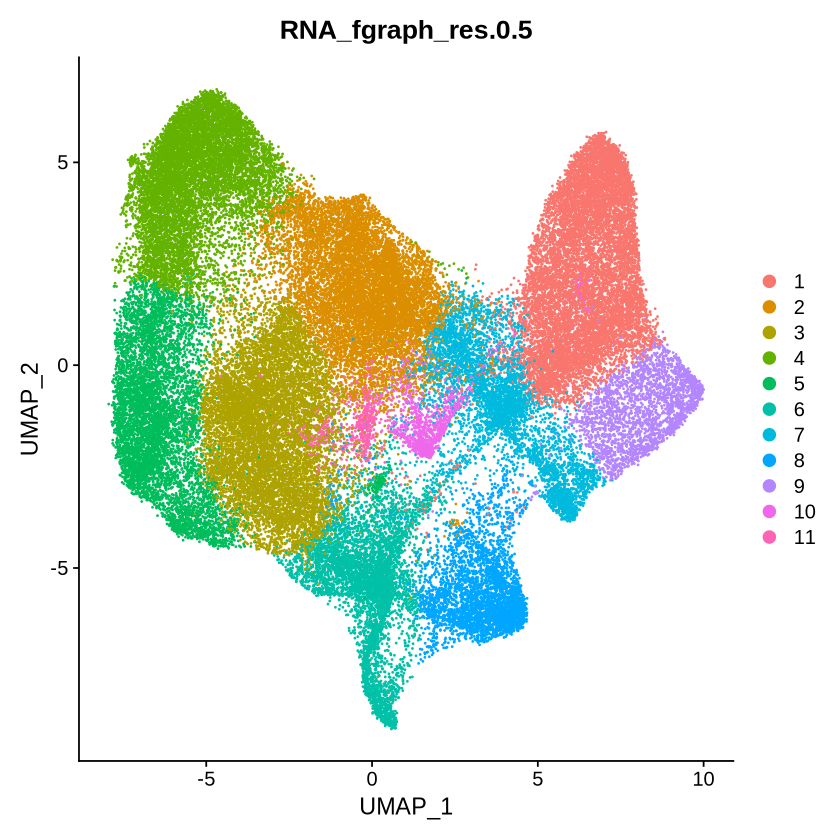

In [13]:
DimPlot(xenium.tiles, reduction='umap', group.by='RNA_fgraph_res.0.5')